In [130]:
%load_ext autoreload
%autoreload 2


from paper_utils import *


def get_arg_df(configs):
    # now add the config args to both dfs
    arg_df = []
    for wandbid, config in configs.items():
        try:
            arg_df.append([wandbid] + [config[arg.replace('.', '_')] for arg in args])
        except:
            arg_df.append([wandbid] + [config[arg] for arg in args])
        
    arg_df = pd.DataFrame(arg_df, columns=['wandbid'] + ['c.' + arg for arg in args])

    unique_cols = []
    for column in arg_df.columns[1:]:
        if column in ['name', 'c.slurmid', 'c.state']:
            continue
        if len(arg_df[column].unique()) > 1:
            unique_cols += [column]
    uniq_name = 'UNIQ-' + '-'.join(unique_cols)
    arg_df[uniq_name] = arg_df.apply(
        lambda x: '-'.join([str(x[col]) for col in unique_cols]),
        axis=1)


    return arg_df, uniq_name, unique_cols

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [714]:
import wandb

api = wandb.Api()
api_runs = api.runs('goatml/semantic_uncertainty')


In [715]:
# args = ['state', 'slurmid', 'dataset', 'model_name', 'metric', 'entailment_model']

args = ['state', 'slurmid', 'dataset', 'model_name', 'metric', 'entailment_model']


configs = {}

for run in api_runs[:100]:
    # finished = run.state == 'finished'
    # lot = 'run_25_nov' in run.description
    # if finished:

    configs[run.id] = run.config
    configs[run.id]['state'] = run.state
    configs[run.id]['slurmid'] = run.notes.split(': ')[1].split(',')[0]

In [716]:
tmp_arg_df, _, _ = get_arg_df(configs)

with pd.option_context('display.max_rows', None):
    tmp = tmp_arg_df.set_index('c.metric').loc['llm_gpt-4'].set_index('c.state').loc['finished']
    display(tmp) #need display to show the dataframe when using with in jupyter

,wandbid,c.slurmid,c.dataset,c.model_name,c.entailment_model,UNIQ-c.dataset-c.model_name-c.metric-c.entailment_model
c.state,,,,,,
finished,1pkhq510,173011,trivia_qa,Llama-2-13b-chat,gpt-3.5,trivia_qa-Llama-2-13b-chat-llm_gpt-4-gpt-3.5
finished,csqqhso7,173013,svamp,Llama-2-13b-chat,gpt-3.5,svamp-Llama-2-13b-chat-llm_gpt-4-gpt-3.5
finished,b8mbxsg4,173015,bioasq,falcon-7b-instruct,gpt-3.5,bioasq-falcon-7b-instruct-llm_gpt-4-gpt-3.5
finished,0xauxgy4,173012,squad,Llama-2-13b-chat,gpt-3.5,squad-Llama-2-13b-chat-llm_gpt-4-gpt-3.5
finished,mzx43pb8,173018,svamp,falcon-7b-instruct,gpt-3.5,svamp-falcon-7b-instruct-llm_gpt-4-gpt-3.5
finished,yctf458k,173019,nq,falcon-7b-instruct,gpt-3.5,nq-falcon-7b-instruct-llm_gpt-4-gpt-3.5
finished,0ssvgj9k,173016,trivia_qa,falcon-7b-instruct,gpt-3.5,trivia_qa-falcon-7b-instruct-llm_gpt-4-gpt-3.5
finished,6nas983b,173017,squad,falcon-7b-instruct,gpt-3.5,squad-falcon-7b-instruct-llm_gpt-4-gpt-3.5
finished,spgwcck1,173014,nq,Llama-2-13b-chat,gpt-3.5,nq-Llama-2-13b-chat-llm_gpt-4-gpt-3.5


Sweep over models and datasets.

* For large llama, have ablation over entailment model and metric.
* Some falcon runs failed due to rare error

In [718]:
runs = {
    'fmqxf9ie': 'bioasq-Llama-2-70b-chat', # g144xlp2
    'grar15m5': 'bioasq-Llama-2-7b-chat',
    'nbcamoof': 'bioasq-falcon-40b-instruct',
    'm56crr5d': 'bioasq-Mistral-7B-Instruct-v0.1',
    'b8mbxsg4': 'bioasq-falcon-7b-instruct',	
    'm5kf4xrf': 'bioasq-Llama-2-13b-chat',

    'abx2s4ve': 'trivia_qa-Llama-2-70b-chat',
    '64gkizzd': 'trivia_qa-Llama-2-7b-chat',
    'pfvp6gbb': 'trivia_qa-falcon-40b-instruct',
    'kfnome0a': 'trivia_qa-Mistral-7B-Instruct-v0.1',
    '0ssvgj9k': 'trivia_qa-falcon-7b-instruct',
    '1pkhq510': 'trivia_qa-Llama-2-13b-chat',

    'nvgkz80j': 'squad-Llama-2-70b-chat',
    'pp7d12fm': 'squad-Llama-2-7b-chat',
    'a4nah729': 'squad-falcon-40b-instruct',  # i26x8noh
    'nlk5ysql': 'squad-Mistral-7B-Instruct-v0.1',
    '6nas983b': 'squad-falcon-7b-instruct',
    '0xauxgy4': 'squad-Llama-2-13b-chat',

    'tph6z33j': 'svamp-Llama-2-70b-chat-8bit',
    'zw3hnj0b': 'svamp-Llama-2-7b-chat-8bit',
    'mz7dlrvt': 'svamp-falcon-40b-instruct',
    'klza56qe': 'svamp-Mistral-7B-Instruct-v0.1',
    'mzx43pb8': 'svamp-falcon-7b-instruct',	
    'csqqhso7': 'svamp-Llama-2-13b-chat',  # finished

    'qpp3a3m3': 'nq-Llama-2-70b-chat-8bit',
    '86mu0ogq': 'nq-Llama-2-7b-chat-8bit',
    'ab1d15w8': 'nq-falcon-40b-instruct',
    '34huu9mg': 'nq-Mistral-7B-Instruct-v0.1',
    'yctf458k': 'nq-falcon-7b-instruct',
    'spgwcck1': 'nq-Llama-2-13b-chat',

}


# raise "i've cancelled two runs after the generate stage to free up gpus for other runs! compute_uncertainty does not need gpus anymore"
# 172454
# sbatch --cpus-per-task=8 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --entailment_model=gpt-3.5 --eval_wandb_runid=g144xlp2
# sbatch --cpus-per-task=8 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --entailment_model=gpt-3.5 --eval_wandb_runid=i26x8noh



In [719]:
args = ['state', 'slurmid', 'dataset', 'model_name', 'metric', 'entailment_model']

configs = {}
for run in runs:
    run = api.run(f'goatml/semantic_uncertainty/{run}')
    cfg = run.config

    if eval := cfg.get('eval_wandb_runid'):
        print(f'Warning: blindly taking generate_answers cfg from {eval} instead of compute_uncertainty cfg for {run}')
        cfg = api.run(f'goatml/semantic_uncertainty/{eval}').config
        
    configs[run.id] = cfg
    configs[run.id]['state'] = run.state
    configs[run.id]['slurmid'] = run.notes.split(': ')[1].split(',')[0]

arg_df, uniq_name, unique_cols = get_arg_df(configs)
arg_df['c.model_name'] = arg_df['c.model_name'].map(lambda x: x if not x.endswith('-8bit') else x[:-len('-8bit')])
arg_df

,wandbid,c.state,c.slurmid,c.dataset,c.model_name,c.metric,c.entailment_model,UNIQ-c.dataset-c.model_name
0,fmqxf9ie,finished,172454,bioasq,Llama-2-70b-chat,llm_gpt-4,gpt-3.5,bioasq-Llama-2-70b-chat
1,grar15m5,finished,171895,bioasq,Llama-2-7b-chat,llm_gpt-4,gpt-3.5,bioasq-Llama-2-7b-chat
2,nbcamoof,finished,171885,bioasq,falcon-40b-instruct,llm_gpt-4,gpt-3.5,bioasq-falcon-40b-instruct
3,m56crr5d,finished,172443,bioasq,Mistral-7B-Instruct-v0.1,llm_gpt-4,gpt-3.5,bioasq-Mistral-7B-Instruct-v0.1
4,b8mbxsg4,finished,173015,bioasq,falcon-7b-instruct,llm_gpt-4,gpt-3.5,bioasq-falcon-7b-instruct
5,m5kf4xrf,finished,173010,bioasq,Llama-2-13b-chat,llm_gpt-4,gpt-3.5,bioasq-Llama-2-13b-chat
6,abx2s4ve,finished,171898,trivia_qa,Llama-2-70b-chat,llm_gpt-4,gpt-3.5,trivia_qa-Llama-2-70b-chat
7,64gkizzd,finished,171900,trivia_qa,Llama-2-7b-chat,llm_gpt-4,gpt-3.5,trivia_qa-Llama-2-7b-chat
8,pfvp6gbb,finished,171914,trivia_qa,falcon-40b-instruct,llm_gpt-4,gpt-3.5,trivia_qa-falcon-40b-instruct
9,kfnome0a,finished,172444,trivia_qa,Mistral-7B-Instruct-v0.1,llm_gpt-4,gpt-3.5,trivia_qa-Mistral-7B-Instruct-v0.1


In [642]:
for value in ['c.state', 'wandbid', 'c.slurmid']:
    display(arg_df.pivot(index='c.dataset', columns='c.model_name', values=value))

c.model_name,Llama-2-70b-chat,Llama-2-7b-chat,Mistral-7B-Instruct-v0.1,falcon-40b-instruct
c.dataset,,,,
bioasq,finished,finished,finished,finished
nq,finished,finished,finished,finished
squad,finished,finished,finished,finished
svamp,finished,finished,finished,finished
trivia_qa,finished,finished,finished,finished


c.model_name,Llama-2-70b-chat,Llama-2-7b-chat,Mistral-7B-Instruct-v0.1,falcon-40b-instruct
c.dataset,,,,
bioasq,fmqxf9ie,grar15m5,m56crr5d,nbcamoof
nq,qpp3a3m3,86mu0ogq,34huu9mg,ab1d15w8
squad,nvgkz80j,pp7d12fm,nlk5ysql,a4nah729
svamp,tph6z33j,zw3hnj0b,klza56qe,mz7dlrvt
trivia_qa,abx2s4ve,64gkizzd,kfnome0a,pfvp6gbb


c.model_name,Llama-2-70b-chat,Llama-2-7b-chat,Mistral-7B-Instruct-v0.1,falcon-40b-instruct
c.dataset,,,,
bioasq,172454,171895,172443,171885
nq,172442,172627,172630,172508
squad,171899,171901,172445,172455
svamp,172441,172470,172629,172495
trivia_qa,171898,171900,172444,171914


In [341]:
# compare configs between models (same dataset):

for groupby in (['c.dataset', 'c.model_name']):
    print(80 * 'x')
    print(f'Groupby {groupby}')
    
    for dataset, gdf in arg_df.groupby(groupby):
        print(80 * '-')
        print(f'{groupby}: {dataset}')
    
        wandb_ids = gdf.wandbid.values
        base, other = wandb_ids[0], wandb_ids[1:]
    
        name = lambda x: ' '.join(arg_df.set_index('wandbid').loc[x][['c.dataset', 'c.model_name']])
        cfg = deepcopy(configs)
        cfg[base].pop('slurmid')
        cfg[base].pop('state')
        for o in other:
            cfg[o].pop('slurmid')
            cfg[o].pop('state')
            print(f'{base} / {name(base)} vs {o} / {name(o)}')
            print(DeepDiff(cfg[base], cfg[o]))
        

xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Groupby c.dataset
--------------------------------------------------------------------------------
c.dataset: bioasq
fmqxf9ie / bioasq Llama-2-70b-chat vs grar15m5 / bioasq Llama-2-7b-chat
{'values_changed': {"root['model_name']": {'new_value': 'Llama-2-7b-chat', 'old_value': 'Llama-2-70b-chat'}, "root['p_true_num_fewshot']": {'new_value': 7, 'old_value': 6}}}
fmqxf9ie / bioasq Llama-2-70b-chat vs nbcamoof / bioasq falcon-40b-instruct
{'values_changed': {"root['model_name']": {'new_value': 'falcon-40b-instruct', 'old_value': 'Llama-2-70b-chat'}, "root['p_true_num_fewshot']": {'new_value': 2, 'old_value': 6}}}
fmqxf9ie / bioasq Llama-2-70b-chat vs m56crr5d / bioasq Mistral-7B-Instruct-v0.1
{'values_changed': {"root['model_name']": {'new_value': 'Mistral-7B-Instruct-v0.1', 'old_value': 'Llama-2-70b-chat'}, "root['p_true_num_fewshot']": {'new_value': 2, 'old_value': 6}}}
--------------------------------------

Runs look coherent within each other!

(use_context deos not matter for bioasq!)

Last thing that's needed to check: how do they compare against my previous 'almost perfect' runs?

In [54]:
# expected differences: 15 gens, llm_metric, gpt4_entailment
# old generate answers trivia_qa
DeepDiff(api.run('goatml/semantic_uncertainty/1gxo9oef').config, configs['abx2s4ve'])

{'dictionary_item_added': [root['random_seed'], root['recompute_accuracy'], root['compute_accuracy_at_all_temps'], root['state'], root['wandbid'], root['slurmid']],
 'values_changed': {"root['metric']": {'new_value': 'llm_gpt-4',
   'old_value': 'llm'},
  "root['model_name']": {'new_value': 'Llama-2-70b-chat',
   'old_value': 'Llama-2-70b-chat-8bit'},
  "root['num_generations']": {'new_value': 10, 'old_value': 15},
  "root['entailment_model']": {'new_value': 'gpt-3.5', 'old_value': 'gpt-4'},
  "root['p_true_num_fewshot']": {'new_value': 10, 'old_value': 5}}}

In [55]:
# generate answers squad
DeepDiff(api.run('goatml/semantic_uncertainty/uvfbxm6d').config, configs['nvgkz80j'])

{'dictionary_item_added': [root['random_seed'], root['recompute_accuracy'], root['compute_accuracy_at_all_temps'], root['state'], root['wandbid'], root['slurmid']],
 'values_changed': {"root['metric']": {'new_value': 'llm_gpt-4',
   'old_value': 'llm'},
  "root['model_name']": {'new_value': 'Llama-2-70b-chat',
   'old_value': 'Llama-2-70b-chat-8bit'},
  "root['num_generations']": {'new_value': 10, 'old_value': 15},
  "root['entailment_model']": {'new_value': 'gpt-3.5', 'old_value': 'gpt-4'},
  "root['p_true_num_fewshot']": {'new_value': 5, 'old_value': 2}}}

In [56]:
# generate answers bioasq
DeepDiff(api.run('goatml/semantic_uncertainty/dqtye228').config, configs['g144xlp2'])

{'dictionary_item_added': [root['random_seed'], root['recompute_accuracy'], root['compute_accuracy_at_all_temps'], root['state'], root['wandbid'], root['slurmid']],
 'dictionary_item_removed': [root['is_ood_eval']],
 'values_changed': {"root['metric']": {'new_value': 'llm_gpt-4',
   'old_value': 'llm'},
  "root['model_name']": {'new_value': 'Llama-2-70b-chat',
   'old_value': 'Llama-2-70b-chat-8bit'},
  "root['num_generations']": {'new_value': 10, 'old_value': 15},
  "root['entailment_model']": {'new_value': 'gpt-3.5', 'old_value': 'gpt-4'},
  "root['p_true_num_fewshot']": {'new_value': 6, 'old_value': 2}}}

In [409]:
runs = {k: runs[k] for k in runs if arg_df.set_index('wandbid').loc[k]['c.state'] == 'finished'}
runs

{'fmqxf9ie': 'bioasq-Llama-2-70b-chat',
 'grar15m5': 'bioasq-Llama-2-7b-chat',
 'nbcamoof': 'bioasq-falcon-40b-instruct',
 'm56crr5d': 'bioasq-Mistral-7B-Instruct-v0.1',
 'abx2s4ve': 'trivia_qa-Llama-2-70b-chat',
 '64gkizzd': 'trivia_qa-Llama-2-7b-chat',
 'pfvp6gbb': 'trivia_qa-falcon-40b-instruct',
 'kfnome0a': 'trivia_qa-Mistral-7B-Instruct-v0.1',
 'nvgkz80j': 'squad-Llama-2-70b-chat',
 'pp7d12fm': 'squad-Llama-2-7b-chat',
 'a4nah729': 'squad-falcon-40b-instruct',
 'nlk5ysql': 'squad-Mistral-7B-Instruct-v0.1',
 'tph6z33j': 'svamp-Llama-2-70b-chat-8bit',
 'zw3hnj0b': 'svamp-Llama-2-7b-chat-8bit',
 'mz7dlrvt': 'svamp-falcon-40b-instruct',
 'klza56qe': 'svamp-Mistral-7B-Instruct-v0.1',
 'qpp3a3m3': 'nq-Llama-2-70b-chat-8bit',
 'ab1d15w8': 'nq-falcon-40b-instruct',
 '34huu9mg': 'nq-Mistral-7B-Instruct-v0.1'}

In [ ]:
# final set of runs before addinv svamp/nq/mistral
# {'fmqxf9ie': 'bioasq-Llama-2-70b-chat',
#  'grar15m5': 'bioasq-Llama-2-7b-chat',
#  'nbcamoof': 'bioasq-falcon-40b-instruct',
#  'abx2s4ve': 'trivia_qa-Llama-2-70b-chat',
#  '64gkizzd': 'trivia_qa-Llama-2-7b-chat',
#  'pfvp6gbb': 'trivia_qa-falcon-40b-instruct',
#  'nvgkz80j': 'squad-Llama-2-70b-chat',
#  'pp7d12fm': 'squad-Llama-2-7b-chat',
#  'a4nah729': 'squad-falcon-40b-instruct'}


In [720]:
configs = {k: configs[k] for k in runs}

In [721]:
# all_results = {}
for wandb_id in runs:
    if wandb_id not in all_results:
        all_results[wandb_id], _ = restore_file(wandb_id)

model,bioasq,nq,squad,svamp,trivia_qa
dataset,,,,,
Llama-2-13b-chat,0.5550,0.5500,0.3950,0.530000,0.8050
Llama-2-70b-chat,0.6400,NaN,0.4225,NaN,0.8725
Llama-2-70b-chat-8bit,NaN,0.6075,NaN,0.690000,NaN
Llama-2-7b-chat,0.5425,NaN,0.3425,NaN,0.7400
Llama-2-7b-chat-8bit,NaN,0.5075,NaN,0.416667,NaN
Mistral-7B-Instruct-v0.1,0.4950,0.3800,0.2975,0.506667,0.6350
falcon-40b-instruct,0.6025,0.5825,0.3700,0.563333,0.7950
falcon-7b-instruct,0.4275,0.2825,0.2125,0.230000,0.4950


Text(0, 0.5, 'accuracy')

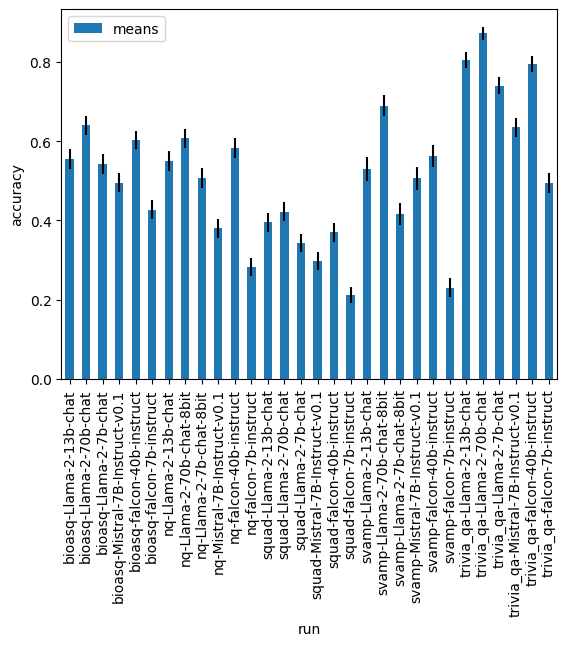

In [722]:
def get_perf_df(runs, all_results=all_results):
    perfdf = {}
    for wandb_id, run_name in runs.items():
        results = all_results[wandb_id]    
        perfdf[wandb_id] = get_perfs(results)
    
    runids = list(perfdf.keys())
    tmp = pd.DataFrame(perfdf[runids[0]])
    tmp['wandbid'] = runids[0]
    tmp['run'] = runs[runids[0]]
    
    for runid in runids[1:]:
        tmp2 = pd.DataFrame(perfdf[runid])
        tmp2['wandbid'] = runid
        tmp2['run'] = runs[runid]
        
        tmp = pd.concat([tmp, tmp2])
    
    perfdf = tmp.reset_index()
    
    tmp = perfdf.set_index('method').loc['accuracy']
    tmp['model'] = tmp.run.map(lambda x: '-'.join(x.split('-')[:1]))
    tmp['dataset'] = tmp.run.map(lambda x: '-'.join(x.split('-')[1:]))
    display(tmp.pivot(columns='model', index='dataset', values='means'))

    pdfs = {}
    for wandb_id in runs:
        results = all_results[wandb_id]
        pdfs[wandb_id] = get_uncertainty_df(results)
    
    runids = list(pdfs.keys())

    tmp = pd.DataFrame(pdfs[runids[0]])
    tmp['run'] = runs[runids[0]]
    tmp['wandbid'] = runids[0]
    
    for runid in runids[1:]:
        tmp2 = pd.DataFrame(pdfs[runid])
        tmp2['run'] = runs[runid]
        tmp2['wandbid'] = runid
    
        tmp = pd.concat([tmp, tmp2])
    
    all_runs = tmp.reset_index()

    return perfdf, pdfs, all_runs

perfdf, pdfs, all_runs = get_perf_df(runs)

perfdf = perfdf.merge(arg_df, on='wandbid')
all_runs = all_runs.merge(arg_df, on='wandbid')

plot_bar(perfdf.set_index('method').loc['accuracy'].set_index('run').sort_index())
plt.gca().set_ylabel('accuracy')

/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)


Text(0, 0.5, 'accuracy')

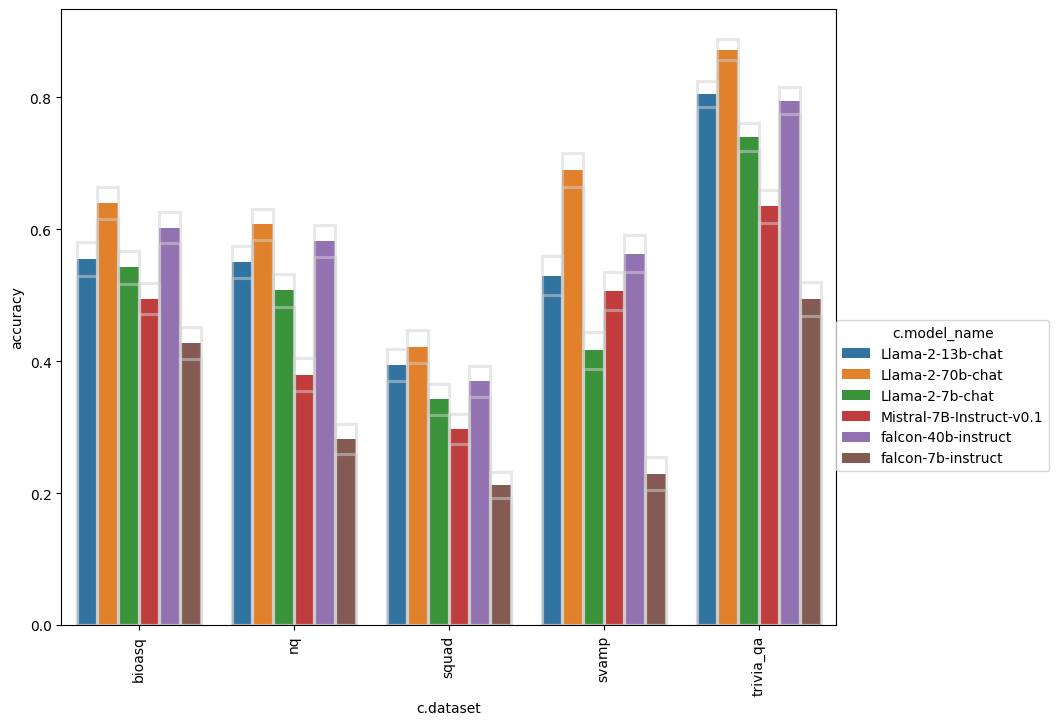

In [723]:
# just select the base entailment_model and metric, and ignore 'max_from' accuracies
acc = 'accuracy'
plot_grouped(perfdf.set_index('method').loc['accuracy'], metric='means', x='c.dataset', hue='c.model_name')
plt.gca().set_ylabel(acc)


In [1037]:
len(pik_runs)

120

In [788]:
# load ood runs for p_ik

pik_runs = {
 'ueysytnh': 'falcon-40b-instruct-svamp-nq',
 'si8o1o3o': 'falcon-40b-instruct-svamp-squad',
 'itt028az': 'falcon-40b-instruct-bioasq-svamp',
 'jimxzgwm': 'falcon-40b-instruct-squad-svamp',
 '8qx4w6pu': 'falcon-40b-instruct-bioasq-squad',
 'szxwvi88': 'falcon-40b-instruct-svamp-bioasq',
 '70v00ze7': 'falcon-40b-instruct-bioasq-nq',
 'gnbhhmbp': 'falcon-40b-instruct-squad-nq',
 'vkrfbq14': 'Mistral-7B-Instruct-v0.1-trivia_qa-squad',
 'xnwy93zh': 'Mistral-7B-Instruct-v0.1-nq-trivia_qa',
 'e7u6a42p': 'Mistral-7B-Instruct-v0.1-trivia_qa-svamp',
 '2c6skk6g': 'falcon-40b-instruct-squad-trivia_qa',
 'wqk3twti': 'Mistral-7B-Instruct-v0.1-squad-bioasq',
 '0929rm33': 'falcon-40b-instruct-nq-trivia_qa',
 'sk7xx6a9': 'Mistral-7B-Instruct-v0.1-trivia_qa-bioasq',
 '86xnaea5': 'Mistral-7B-Instruct-v0.1-bioasq-svamp',
 'wa4xw7dn': 'Mistral-7B-Instruct-v0.1-nq-squad',
 '5ytf3m50': 'falcon-40b-instruct-squad-bioasq',
 'g7w0saqf': 'Mistral-7B-Instruct-v0.1-trivia_qa-nq',
 '78ubflxu': 'Mistral-7B-Instruct-v0.1-bioasq-nq',
 'jehdmd18': 'falcon-40b-instruct-nq-bioasq',
 '64rh8qyb': 'Mistral-7B-Instruct-v0.1-nq-bioasq',
 'bqhpmgd5': 'Mistral-7B-Instruct-v0.1-svamp-trivia_qa',
 '5auzcurn': 'Llama-2-70b-chat-trivia_qa-svamp',
 'ix8o3ar9': 'Llama-2-7b-chat-trivia_qa-svamp',
 'xw2oxw14': 'Mistral-7B-Instruct-v0.1-svamp-squad',
 'k2y3iypk': 'falcon-40b-instruct-bioasq-trivia_qa',
 'lzwbjj0u': 'Mistral-7B-Instruct-v0.1-squad-svamp',
 'ektr1wx1': 'Llama-2-70b-chat-trivia_qa-squad',
 's2b3dq5z': 'Llama-2-7b-chat-trivia_qa-squad',
 'g0563a58': 'falcon-40b-instruct-nq-squad',
 'tojydb0d': 'Mistral-7B-Instruct-v0.1-svamp-bioasq',
 'c8p7ona4': 'Mistral-7B-Instruct-v0.1-nq-svamp',
 'r5jrwa0p': 'Llama-2-70b-chat-trivia_qa-nq',
 '28is5g4g': 'Mistral-7B-Instruct-v0.1-bioasq-squad',
 'sd6mwmt4': 'Mistral-7B-Instruct-v0.1-squad-trivia_qa',
 '50kln4yq': 'falcon-40b-instruct-nq-svamp',
 'qmb1uu6c': 'Llama-2-7b-chat-svamp-bioasq',
 'akbz2zit': 'Mistral-7B-Instruct-v0.1-squad-nq',
 'iztfq74f': 'Llama-2-70b-chat-trivia_qa-bioasq',
 '22n8akov': 'Llama-2-7b-chat-trivia_qa-bioasq',
 'vik61pbd': 'Llama-2-70b-chat-squad-trivia_qa',
 'v1uuwmni': 'Llama-2-7b-chat-svamp-trivia_qa',
 '64mwf45o': 'Mistral-7B-Instruct-v0.1-svamp-nq',
 'vasvluw9': 'Mistral-7B-Instruct-v0.1-bioasq-trivia_qa',
 'mj98zcis': 'Llama-2-7b-chat-svamp-squad',
 '1pcia04j': 'Llama-2-7b-chat-bioasq-squad',
 '5bumj7c2': 'Llama-2-70b-chat-squad-svamp',
 'p9cad6z3': 'Llama-2-7b-chat-squad-trivia_qa',
 'b4mm06ws': 'Llama-2-70b-chat-svamp-bioasq',
 '588kp7t1': 'falcon-40b-instruct-trivia_qa-bioasq',
 'h473y96f': 'Llama-2-70b-chat-squad-nq',
 'ue0gu578': 'Llama-2-7b-chat-squad-svamp',
 'j6mc86id': 'Llama-2-70b-chat-svamp-trivia_qa',
 '39iaj5ss': 'falcon-40b-instruct-svamp-trivia_qa',
 't39a8www': 'Llama-2-70b-chat-squad-bioasq',
 'pbk4bb3v': 'Llama-2-7b-chat-squad-bioasq',
 'ltjjp3jv': 'falcon-40b-instruct-trivia_qa-squad',
 'jij6xvq6': 'Llama-2-70b-chat-svamp-squad',
 '5dxgi7l4': 'Llama-2-70b-chat-nq-svamp',
 'bh9uaw62': 'Llama-2-7b-chat-bioasq-svamp',
 'wazba7ok': 'falcon-40b-instruct-trivia_qa-svamp',
 '6rty54ha': 'Llama-2-70b-chat-bioasq-svamp',
 'yqefd5tw': 'Llama-2-70b-chat-nq-bioasq',
 'e0imxyab': 'Llama-2-70b-chat-bioasq-squad',
 '77h3tvmd': 'Llama-2-70b-chat-svamp-nq',
 '7mkmiodg': 'Llama-2-70b-chat-nq-trivia_qa',
 'bvpw98ih': 'Llama-2-7b-chat-bioasq-trivia_qa',
 'rvvamd9u': 'falcon-40b-instruct-trivia_qa-nq',
 'l9uonw9o': 'Llama-2-70b-chat-nq-squad',
 'ig4qamip': 'Llama-2-70b-chat-bioasq-trivia_qa',
 'fc4j2r3i': 'Llama-2-70b-chat-bioasq-nq',
 'ljcrh54n': 'Llama-2-7b-chat-nq-bioasq',
 'jgc2thy5': 'Llama-2-7b-chat-nq-squad',
 'lciwu77a': 'Llama-2-7b-chat-nq-trivia_qa',
 'hu8cexu0': 'Llama-2-7b-chat-nq-svamp',
 'xnwy93zh': 'Mistral-7B-Instruct-v0.1-nq-trivia_qa',
 '0929rm33': 'falcon-40b-instruct-nq-trivia_qa',
 'wa4xw7dn': 'Mistral-7B-Instruct-v0.1-nq-squad',
 'jehdmd18': 'falcon-40b-instruct-nq-bioasq',
 '64rh8qyb': 'Mistral-7B-Instruct-v0.1-nq-bioasq',
 'g0563a58': 'falcon-40b-instruct-nq-squad',
 'c8p7ona4': 'Mistral-7B-Instruct-v0.1-nq-svamp',
 '50kln4yq': 'falcon-40b-instruct-nq-svamp',
 '5dxgi7l4': 'Llama-2-70b-chat-nq-svamp',
 'yqefd5tw': 'Llama-2-70b-chat-nq-bioasq',
 '7mkmiodg': 'Llama-2-70b-chat-nq-trivia_qa',
 'l9uonw9o': 'Llama-2-70b-chat-nq-squad',
# f7b ll13b extension
 '6765gaoz': 'falcon-7b-instruct-svamp-trivia_qa',
 '8jcw7qax': 'falcon-7b-instruct-svamp-squad',
 '0eao8oq3': 'falcon-7b-instruct-bioasq-squad',
 'dymxjypz': 'falcon-7b-instruct-svamp-bioasq',
 'fq9m4d2n': 'Llama-2-13b-chat-trivia_qa-svamp',
 'nmq8pb9u': 'falcon-7b-instruct-squad-svamp',
 'm9s8mmi9': 'Llama-2-13b-chat-trivia_qa-bioasq',
 'p26l8wnp': 'falcon-7b-instruct-squad-bioasq',
 'u0607ds9': 'Llama-2-13b-chat-svamp-trivia_qa',
 'c9mppu94': 'falcon-7b-instruct-trivia_qa-svamp',
 '2ol4lnv2': 'falcon-7b-instruct-squad-trivia_qa',
 'zd1z46va': 'Llama-2-13b-chat-trivia_qa-squad',
 'v8ouphfq': 'falcon-7b-instruct-trivia_qa-bioasq',
 'xrmhci86': 'falcon-7b-instruct-bioasq-svamp',
 'mp3c1ffd': 'Llama-2-13b-chat-svamp-squad',
 'w2qlthlu': 'falcon-7b-instruct-trivia_qa-squad',
 'kw0u8f69': 'Llama-2-13b-chat-squad-svamp',
 't78j0mi8': 'Llama-2-13b-chat-bioasq-trivia_qa',
 'zza88r6j': 'Llama-2-13b-chat-bioasq-svamp',
 'i244tsey': 'falcon-7b-instruct-bioasq-trivia_qa',
 'utq72d8a': 'Llama-2-13b-chat-svamp-bioasq',
 'mb3welo1': 'Llama-2-13b-chat-squad-trivia_qa',
 'pszpktdk': 'Llama-2-13b-chat-bioasq-squad',
 'q4itj0as': 'Llama-2-13b-chat-squad-bioasq',
 'yvq0rsen': 'Llama-2-13b-chat-trivia_qa-nq',
 'tv6l3k23': 'falcon-7b-instruct-bioasq-nq',
 't4n5f2nq': 'Llama-2-13b-chat-svamp-nq',
 'd21n3mal': 'falcon-7b-instruct-nq-svamp',
 'm4h45h16': 'falcon-7b-instruct-trivia_qa-nq',
 'f02x6m70': 'falcon-7b-instruct-nq-squad',
 'x52k6vbg': 'falcon-7b-instruct-squad-nq',
 'verqxnla': 'falcon-7b-instruct-nq-trivia_qa',
 'z9s4mh7g': 'Llama-2-13b-chat-squad-nq',
 'fgv5s8vm': 'Llama-2-13b-chat-nq-bioasq',
 '1nmpuaab': 'Llama-2-13b-chat-nq-svamp',
 'r77eb3sn': 'falcon-7b-instruct-svamp-nq',
 'k0pg7f7g': 'falcon-7b-instruct-nq-bioasq',
 '6opn6gor': 'Llama-2-13b-chat-nq-trivia_qa',
 '5op565yu': 'Llama-2-13b-chat-bioasq-nq',
 'd39o5hng': 'Llama-2-13b-chat-nq-squad',
# missing llama-2-7b nq ood
 'uli0h53r': 'Llama-2-7b-chat-svamp-nq',
 '4be38e9t': 'Llama-2-7b-chat-trivia_qa-nq',
 'nf1fxqwq': 'Llama-2-7b-chat-squad-nq',
 'lvftle50': 'Llama-2-7b-chat-bioasq-nq',

}

# pik_results = {}
for wandb_id in pik_runs:
    print(wandb_id, list(pik_runs.keys()).index(wandb_id), len(pik_runs))
    if wandb_id not in pik_results:
        pik_results[wandb_id], _ = restore_file(wandb_id)


import pickle
with open('/scratch-ssd/jansen/semantic_uncertainty/pik_ood_sentence.pkl', 'wb') as f:
    pickle.dump([pik_runs, pik_results], f)

# with open('/scratch-ssd/jansen/semantic_uncertainty/pik_ood_short.pkl', 'rb') as f:
#     pik_runs, pik_results = pickle.load(f)



ueysytnh 0 120
si8o1o3o 1 120
itt028az 2 120
jimxzgwm 3 120
8qx4w6pu 4 120
szxwvi88 5 120
70v00ze7 6 120
gnbhhmbp 7 120
vkrfbq14 8 120
xnwy93zh 9 120
e7u6a42p 10 120
2c6skk6g 11 120
wqk3twti 12 120
0929rm33 13 120
sk7xx6a9 14 120
86xnaea5 15 120
wa4xw7dn 16 120
5ytf3m50 17 120
g7w0saqf 18 120
78ubflxu 19 120
jehdmd18 20 120
64rh8qyb 21 120
bqhpmgd5 22 120
5auzcurn 23 120
ix8o3ar9 24 120
xw2oxw14 25 120
k2y3iypk 26 120
lzwbjj0u 27 120
ektr1wx1 28 120
s2b3dq5z 29 120
g0563a58 30 120
tojydb0d 31 120
c8p7ona4 32 120
r5jrwa0p 33 120
28is5g4g 34 120
sd6mwmt4 35 120
50kln4yq 36 120
qmb1uu6c 37 120
akbz2zit 38 120
iztfq74f 39 120
22n8akov 40 120
vik61pbd 41 120
v1uuwmni 42 120
64mwf45o 43 120
vasvluw9 44 120
mj98zcis 45 120
1pcia04j 46 120
5bumj7c2 47 120
p9cad6z3 48 120
b4mm06ws 49 120
588kp7t1 50 120
h473y96f 51 120
ue0gu578 52 120
j6mc86id 53 120
39iaj5ss 54 120
t39a8www 55 120
pbk4bb3v 56 120
ltjjp3jv 57 120
jij6xvq6 58 120
5dxgi7l4 59 120
bh9uaw62 60 120
wazba7ok 61 120
6rty54ha 62 120
yq

In [789]:
pik_perfdf, pik_pdfs, pik_all_runs = get_perf_df(pik_runs, all_results=pik_results)
pik_all_runs['c.dataset'] = pik_all_runs.run.map(lambda x: x.split('-')[-2])
pik_all_runs['c.ood_dataset'] = pik_all_runs.run.map(lambda x: x.split('-')[-1])
pik_all_runs['c.model_name'] = pik_all_runs.run.map(lambda x: '-'.join(x.split('-')[:-2]))
pik_all_runs = pik_all_runs.set_index('method').loc['p_ik'].reset_index()
pik_all_runs['method_real'] = pik_all_runs['method'] + ' ' + pik_all_runs['c.ood_dataset']
pik_all_runs['method'] = 'p_ik_ood'

model,Llama,Mistral,falcon
dataset,,,
2-13b-chat-bioasq-nq,0.555,NaN,NaN
2-13b-chat-bioasq-squad,0.555,NaN,NaN
2-13b-chat-bioasq-svamp,0.555,NaN,NaN
2-13b-chat-bioasq-trivia_qa,0.555,NaN,NaN
2-13b-chat-nq-bioasq,0.550,NaN,NaN
...,...,...,...
7b-instruct-svamp-trivia_qa,NaN,NaN,0.230
7b-instruct-trivia_qa-bioasq,NaN,NaN,0.495
7b-instruct-trivia_qa-nq,NaN,NaN,0.495


In [790]:
# check all runs are there
for model, gdf in pik_all_runs.groupby('c.model_name'):
    print(model)
    display(gdf.set_index('metric').loc['AUROC'].pivot(index='c.dataset', columns='c.ood_dataset', values='means'))

Llama-2-13b-chat


c.ood_dataset,bioasq,nq,squad,svamp,trivia_qa
c.dataset,,,,,
bioasq,NaN,0.567061,0.521966,0.566505,0.528318
nq,0.579520,NaN,0.556616,0.565808,0.630177
squad,0.556570,0.650120,NaN,0.501491,0.632624
svamp,0.563317,0.559748,0.562915,NaN,0.562336
trivia_qa,0.614867,0.776597,0.646361,0.536312,NaN


Llama-2-70b-chat


c.ood_dataset,bioasq,nq,squad,svamp,trivia_qa
c.dataset,,,,,
bioasq,NaN,0.531033,0.490994,0.539469,0.533095
nq,0.558072,NaN,0.616943,0.576341,0.577547
squad,0.527498,0.578601,NaN,0.540767,0.587515
svamp,0.578412,0.595761,0.601527,NaN,0.643551
trivia_qa,0.598629,0.634755,0.634642,0.581662,NaN


Llama-2-7b-chat


...

c.ood_dataset,bioasq,nq,squad,svamp,trivia_qa
c.dataset,,,,,
bioasq,NaN,0.525878,0.582358,0.590234,0.599260
nq,0.601310,NaN,0.594917,0.587781,0.691479
squad,0.600706,0.670056,NaN,0.549388,0.675588
svamp,0.623844,0.659406,0.541607,NaN,0.629445
trivia_qa,0.593140,0.713165,0.622209,0.606812,NaN


falcon-40b-instruct


c.ood_dataset,bioasq,nq,squad,svamp,trivia_qa
c.dataset,,,,,
bioasq,NaN,0.572431,0.544038,0.567525,0.636342
nq,0.570636,NaN,0.554496,0.489579,0.641258
squad,0.552472,0.620495,NaN,0.505255,0.569042
svamp,0.457383,0.551019,0.574687,NaN,0.543385
trivia_qa,0.636256,0.725073,0.559557,0.572442,NaN


falcon-7b-instruct


c.ood_dataset,bioasq,nq,squad,svamp,trivia_qa
c.dataset,,,,,
bioasq,NaN,0.505171,0.475523,0.488572,0.501213
nq,0.587586,NaN,0.581542,0.535629,0.665166
squad,0.555780,0.655163,NaN,0.521718,0.565266
svamp,0.478386,0.460631,0.488801,NaN,0.533283
trivia_qa,0.631213,0.702070,0.573932,0.564506,NaN


/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);


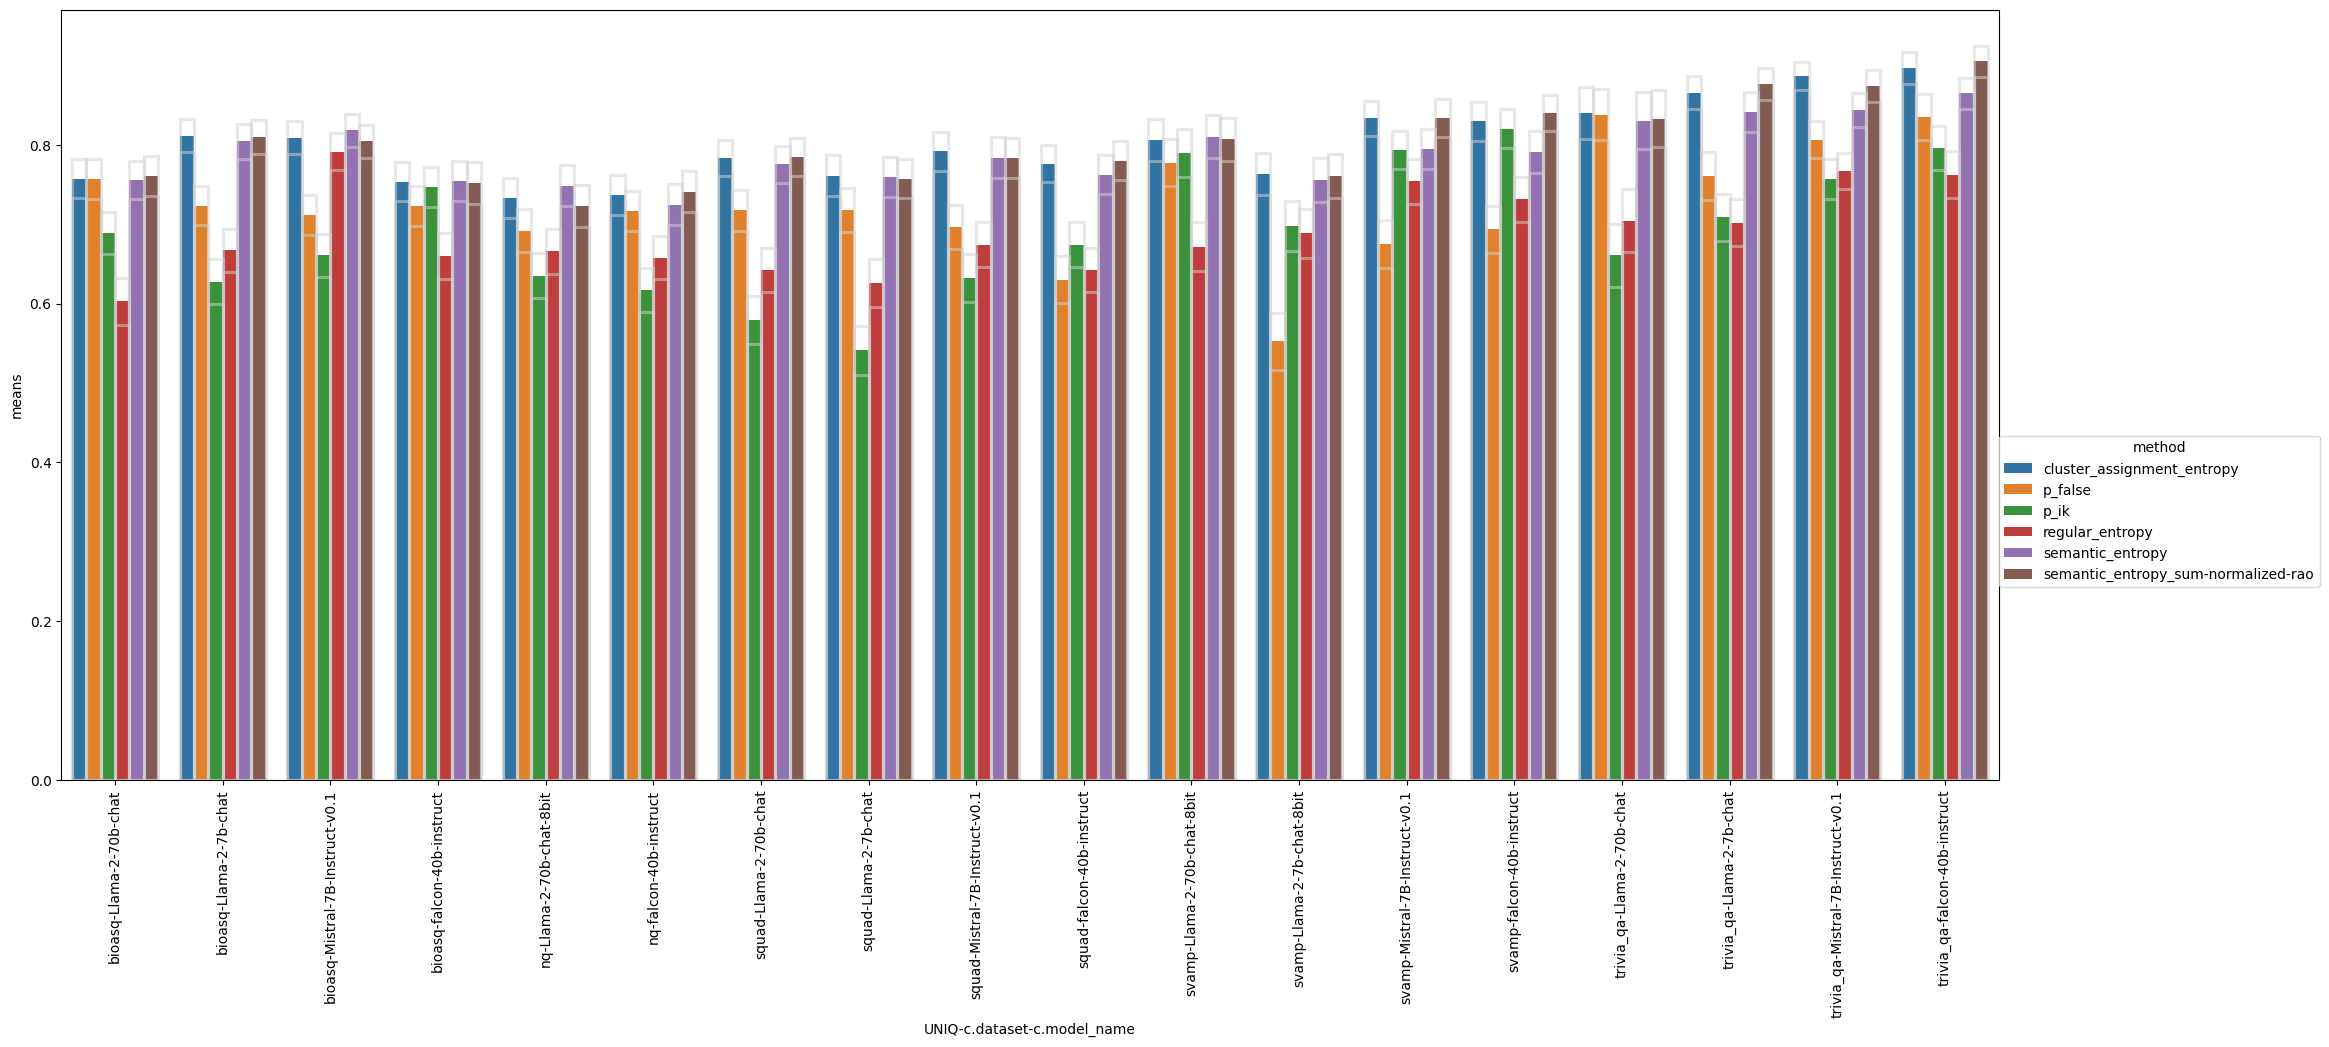

In [398]:

main_methods = ['cluster_assignment_entropy', 'regular_entropy', 'semantic_entropy', 'p_ik', 'p_false', 'semantic_entropy_sum-normalized-rao']
# main_methods = ['regular_entropy', 'p_ik', 'p_false', 'semantic_entropy_sum-normalized-rao']


plot_grouped(
    all_runs.set_index('metric').loc['AUROC'].set_index('method').loc[main_methods].reset_index(),
    metric='means', x=uniq_name, hue='method',
    figsize=(25, 10)
)

/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/us

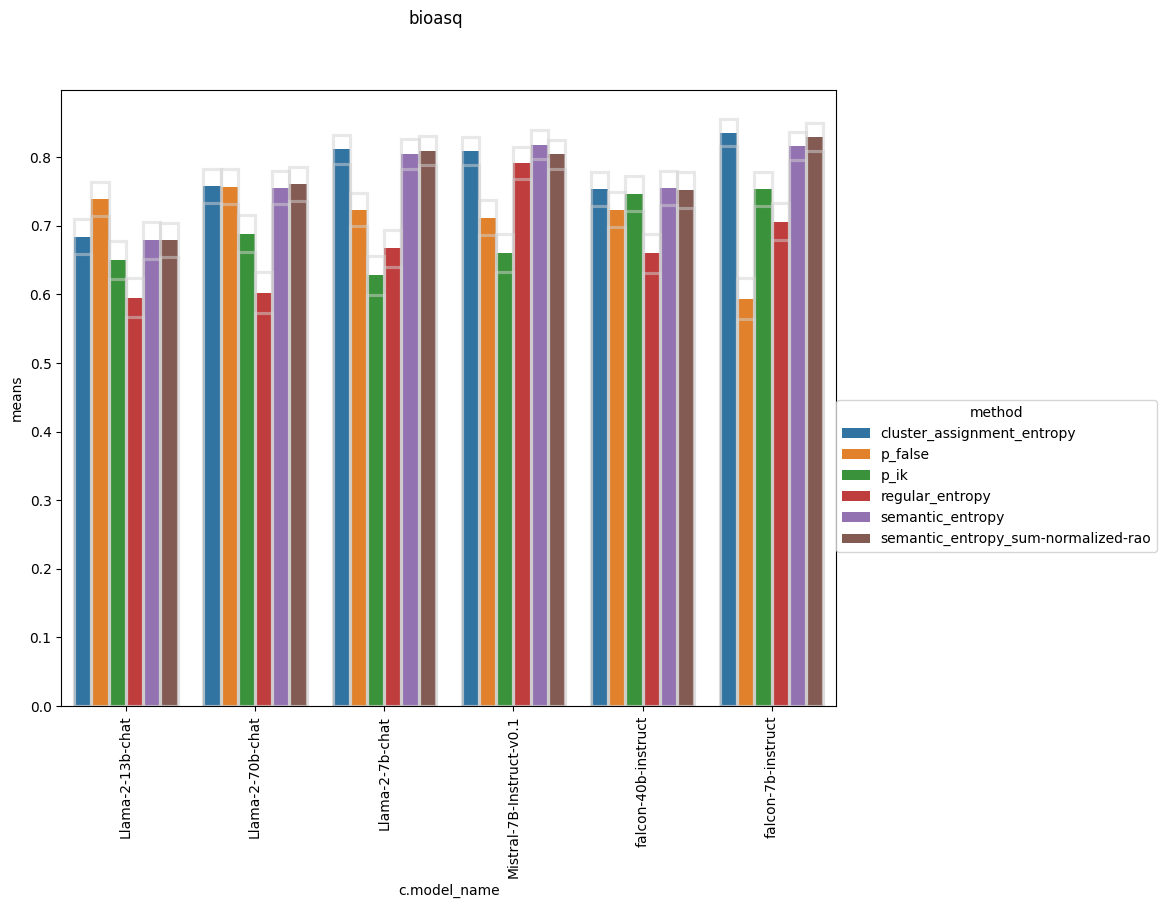

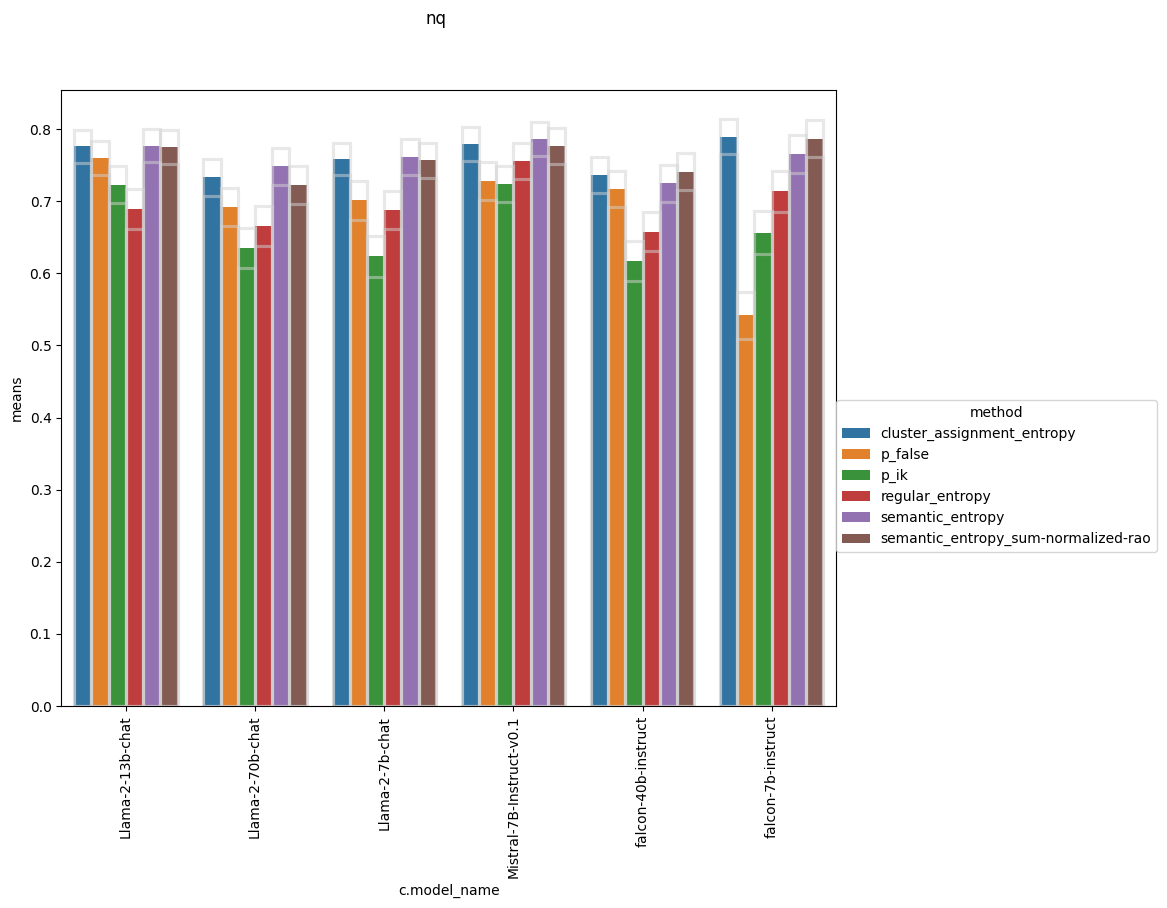

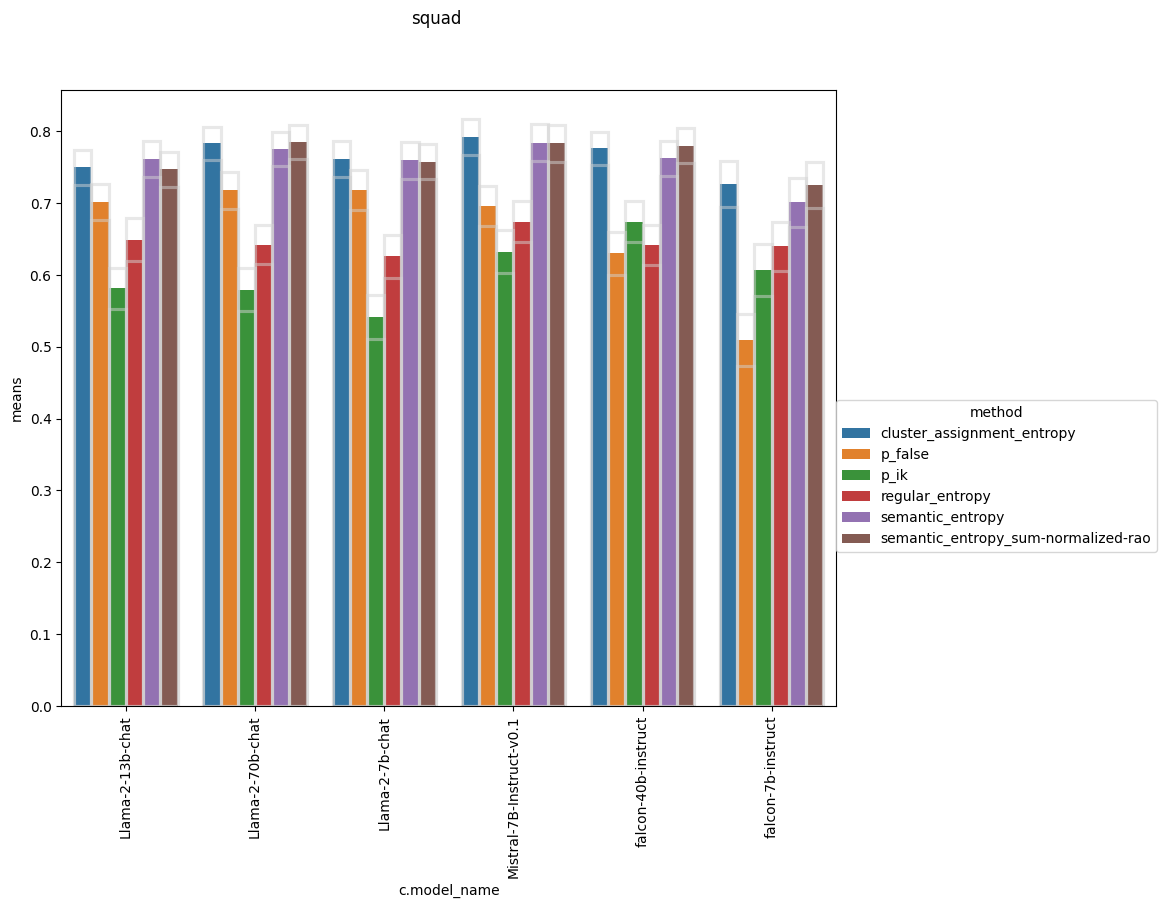

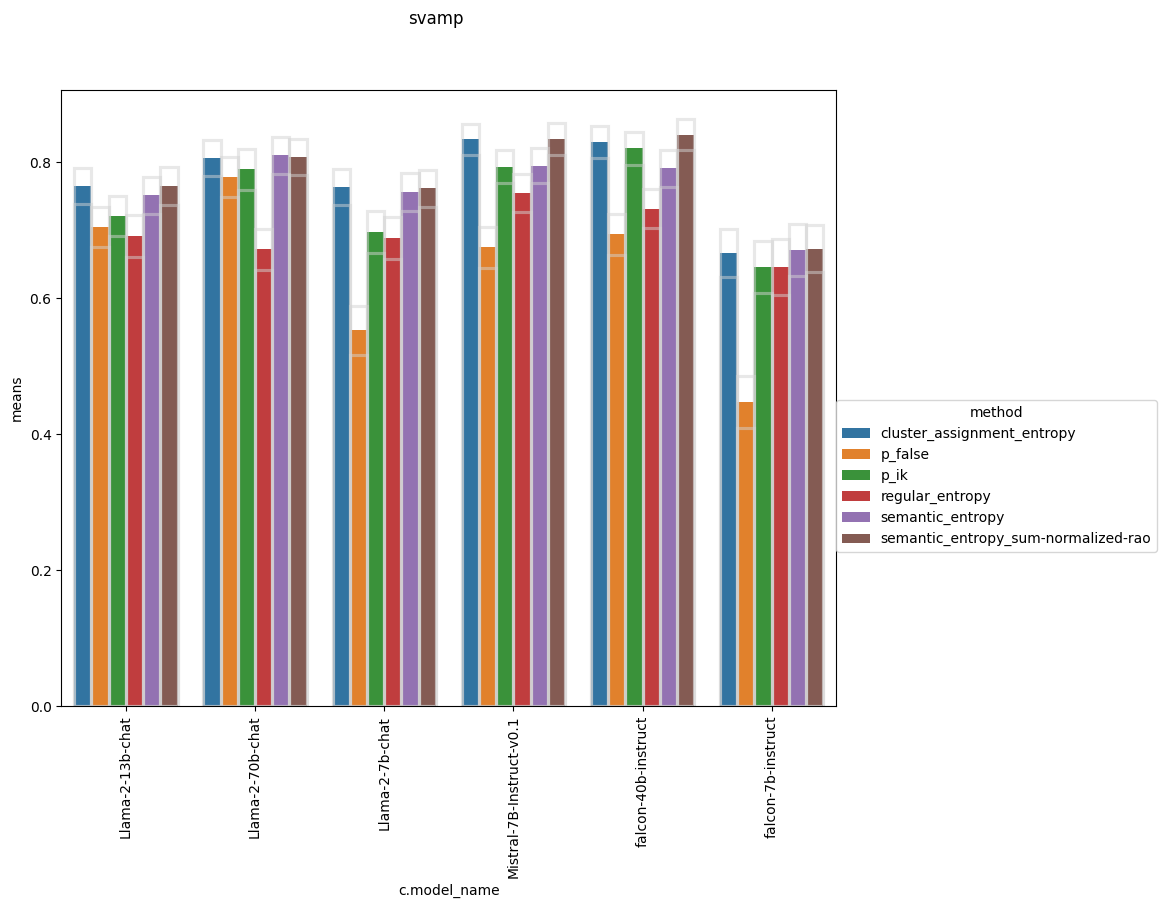

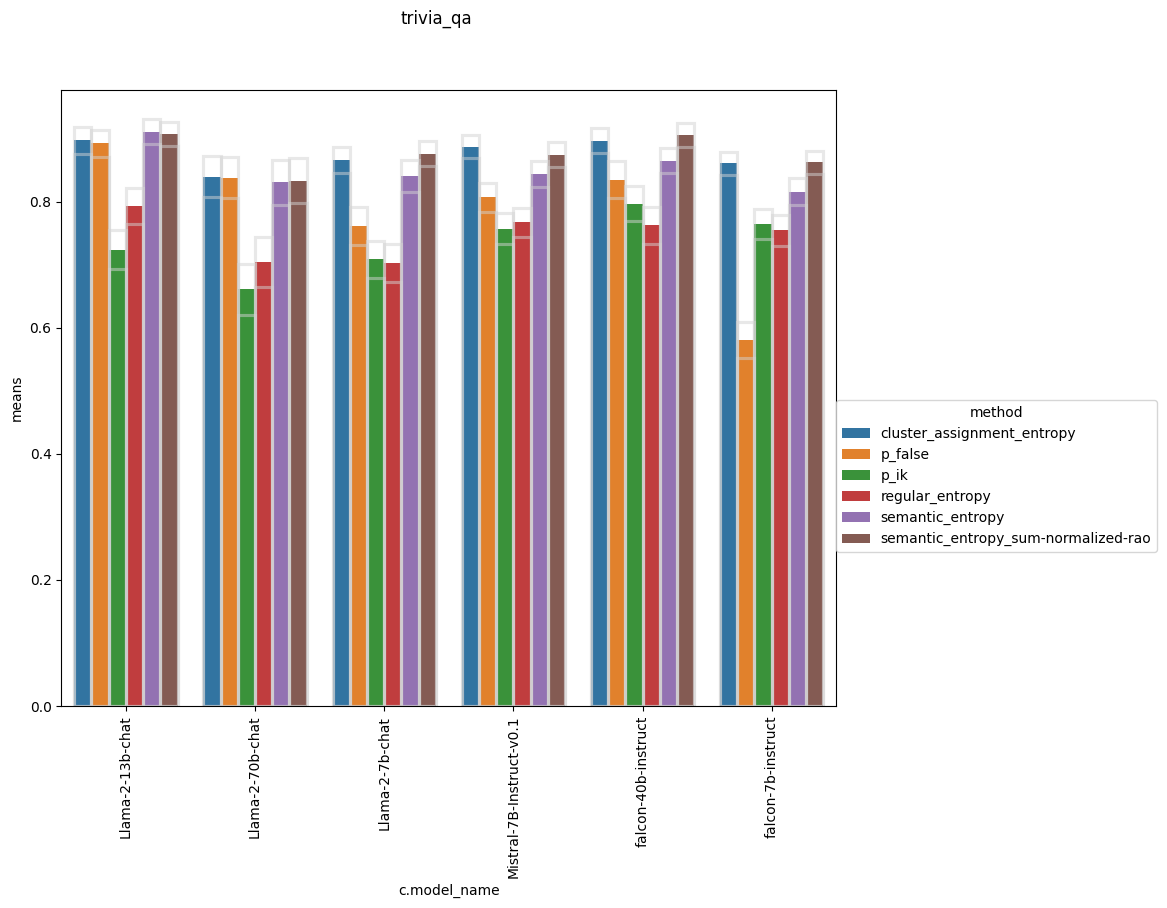

In [725]:
for dataset, gdf in all_runs.groupby('c.dataset'):

    plot_grouped(
        gdf.set_index('metric').loc['AUROC'].set_index('method').loc[main_methods].reset_index(),
        metric='means', x='c.model_name', hue='method',
    )
    plt.gcf().suptitle(dataset)

/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/us

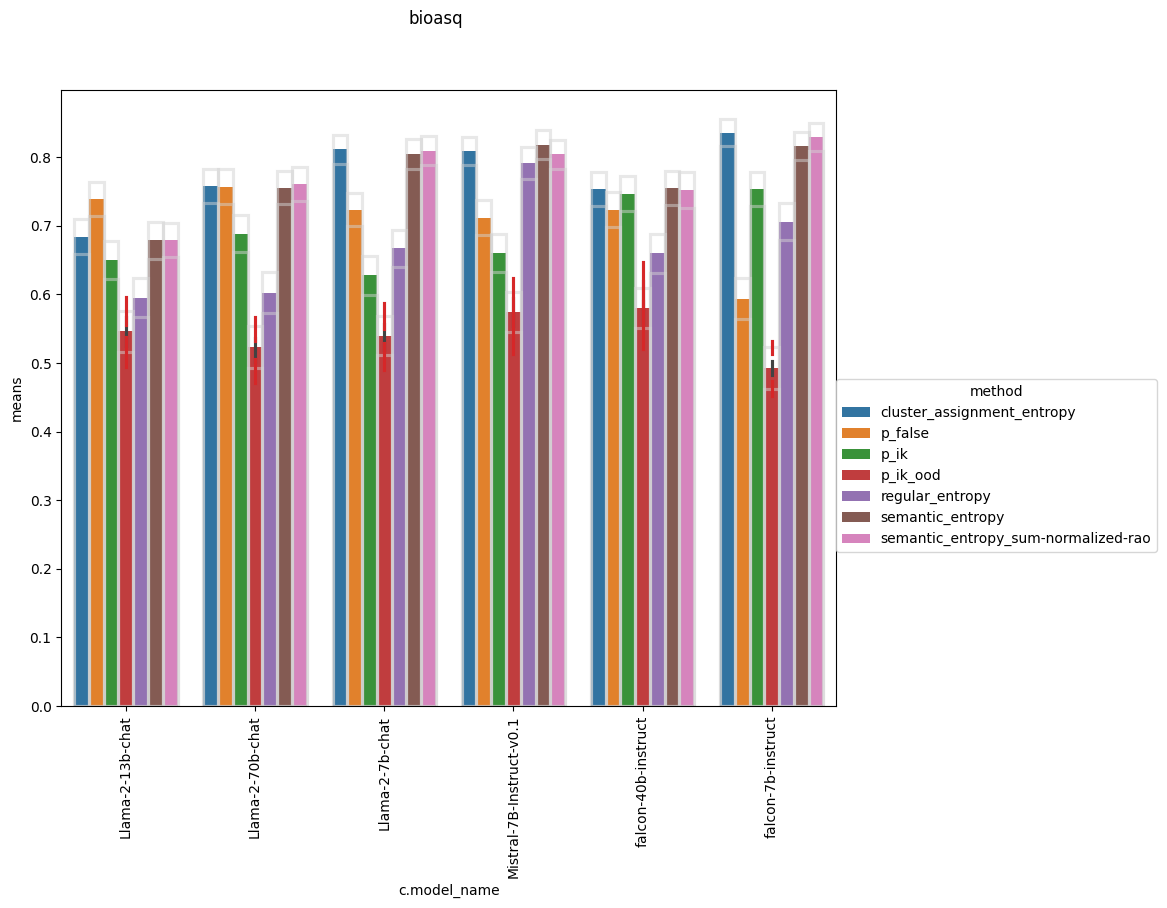

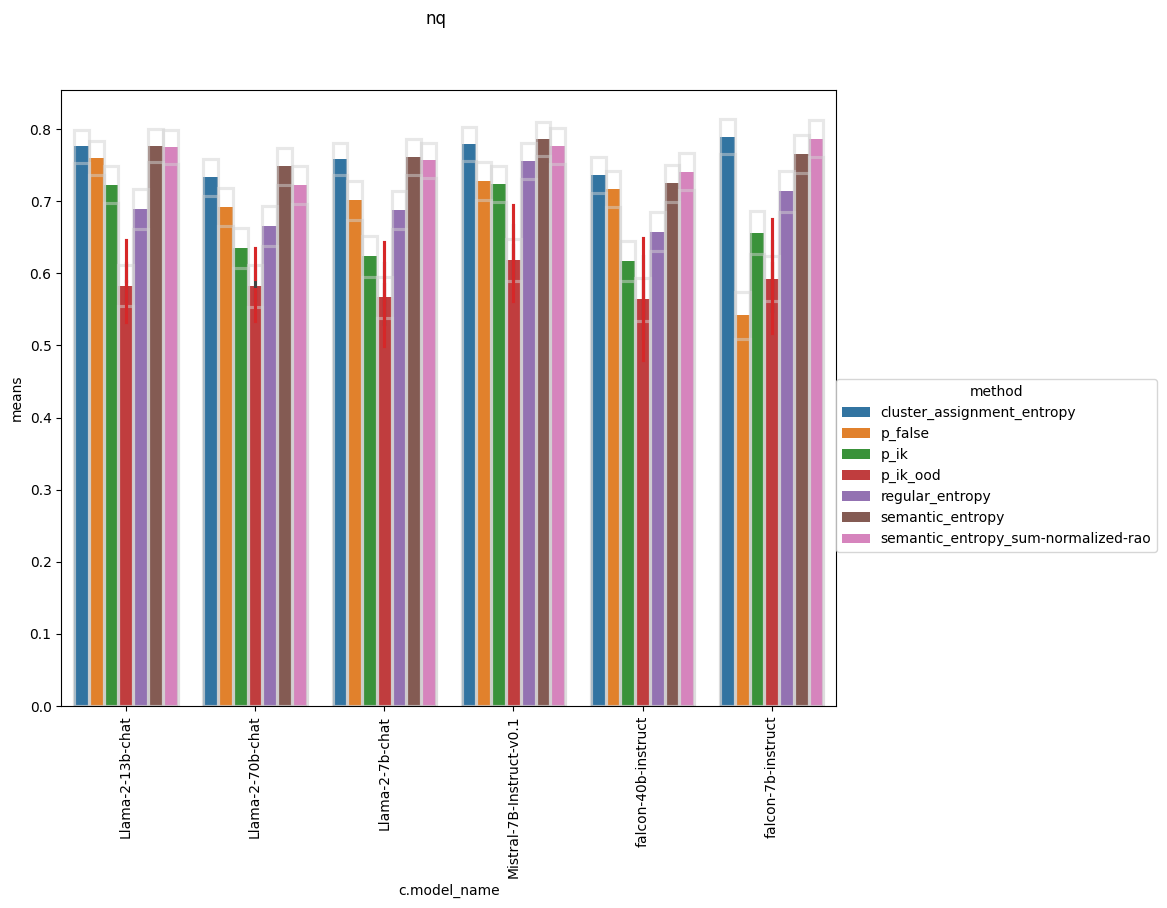

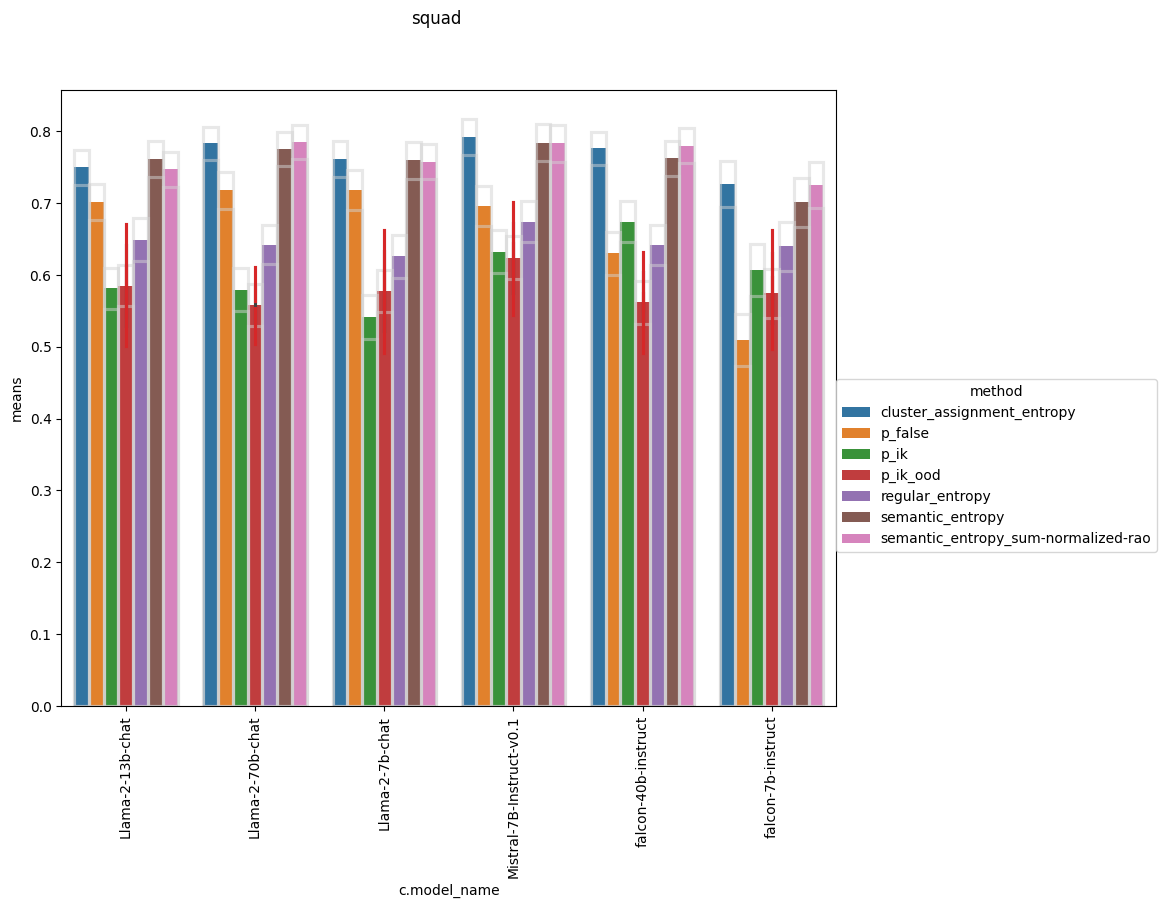

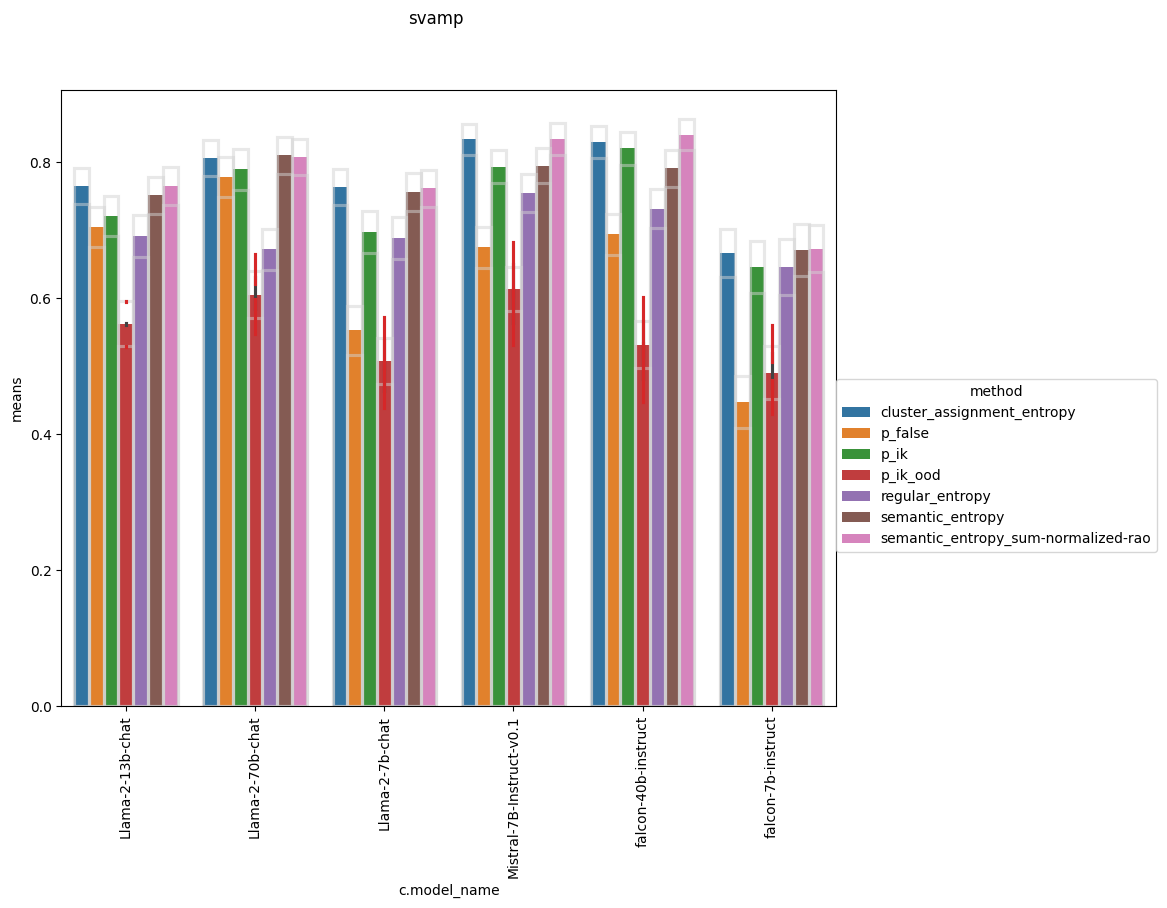

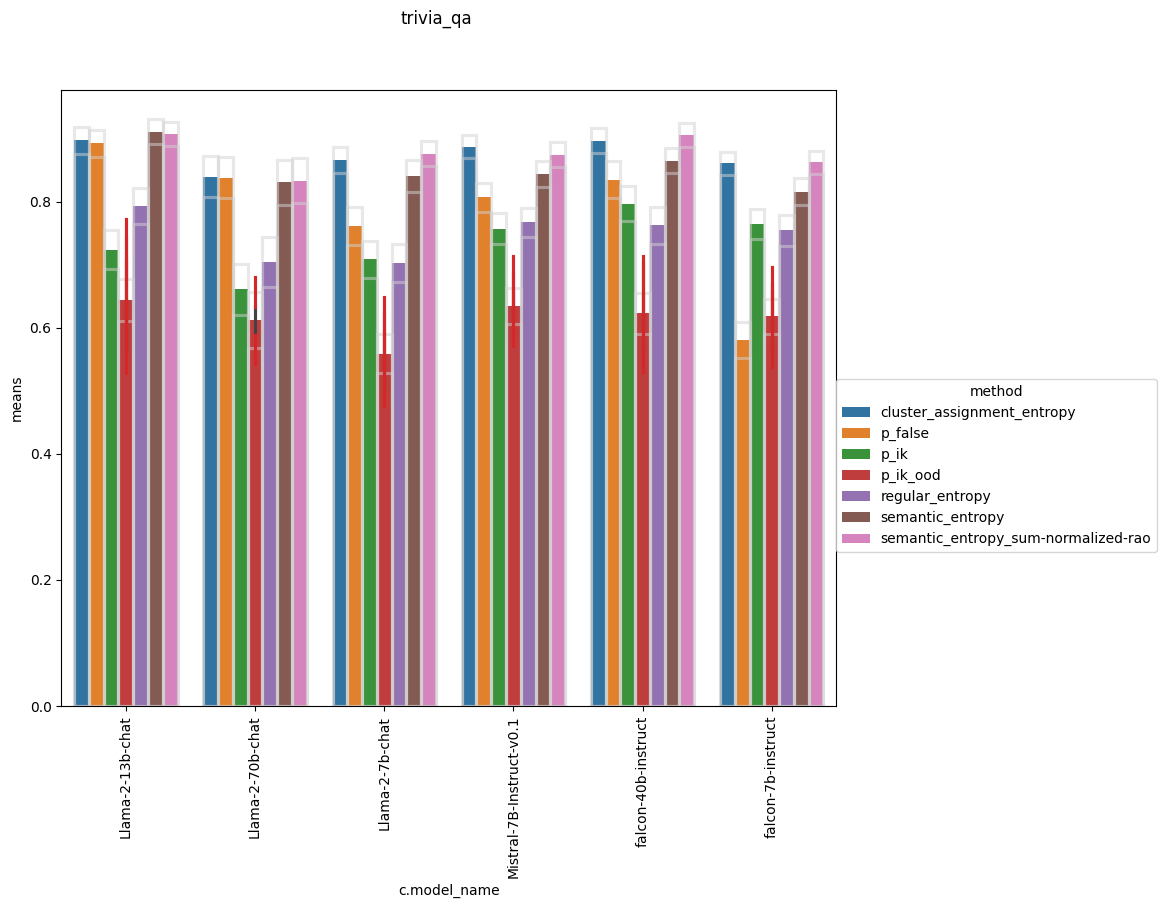

In [791]:
# add average p_ik performance when trained on OOD data
cat_df = pd.concat([pik_all_runs, all_runs])

for dataset, gdf in cat_df.groupby('c.dataset'):

    plot_grouped(
        gdf.set_index('metric').loc['AUROC'].set_index('method').loc[main_methods + ['p_ik_ood']].reset_index(),
        metric='means', x='c.model_name', hue='method',
    )
    plt.gcf().suptitle(dataset)

/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/us

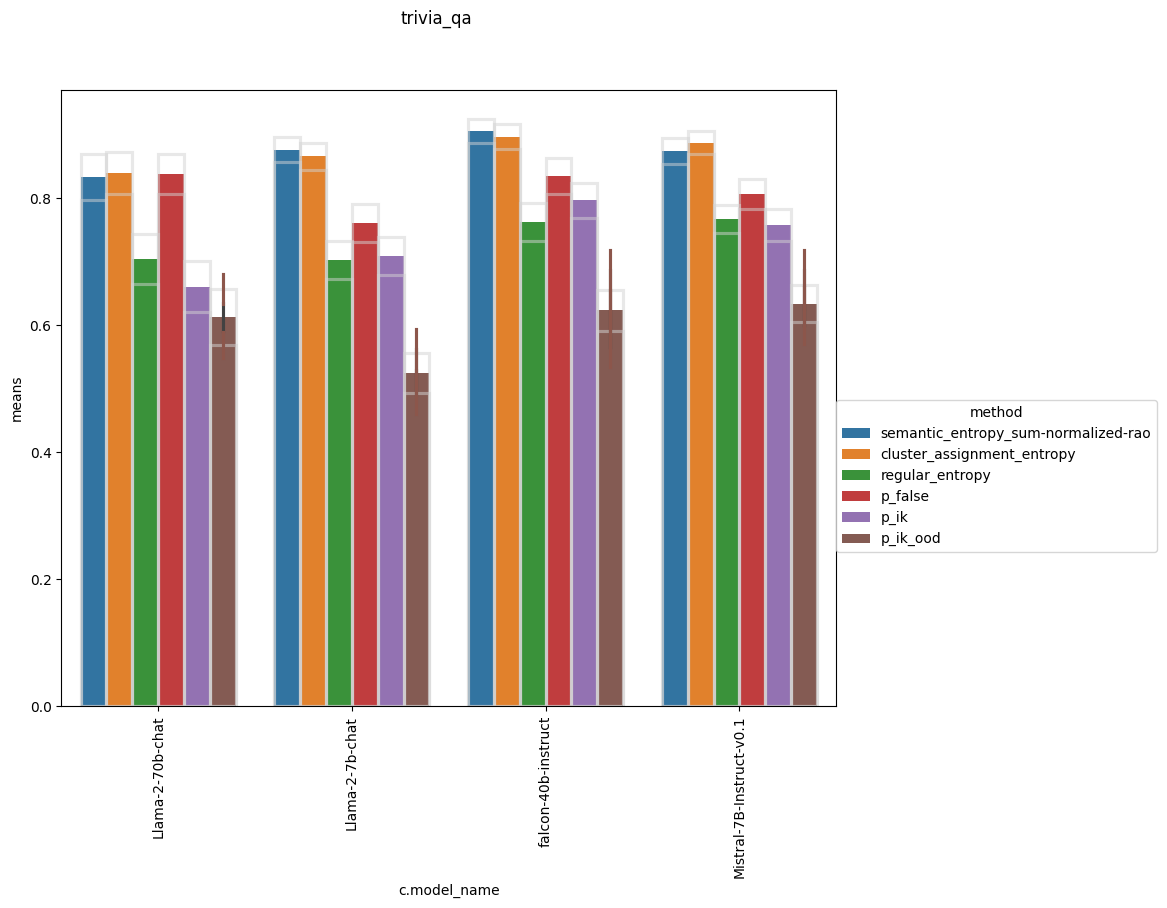

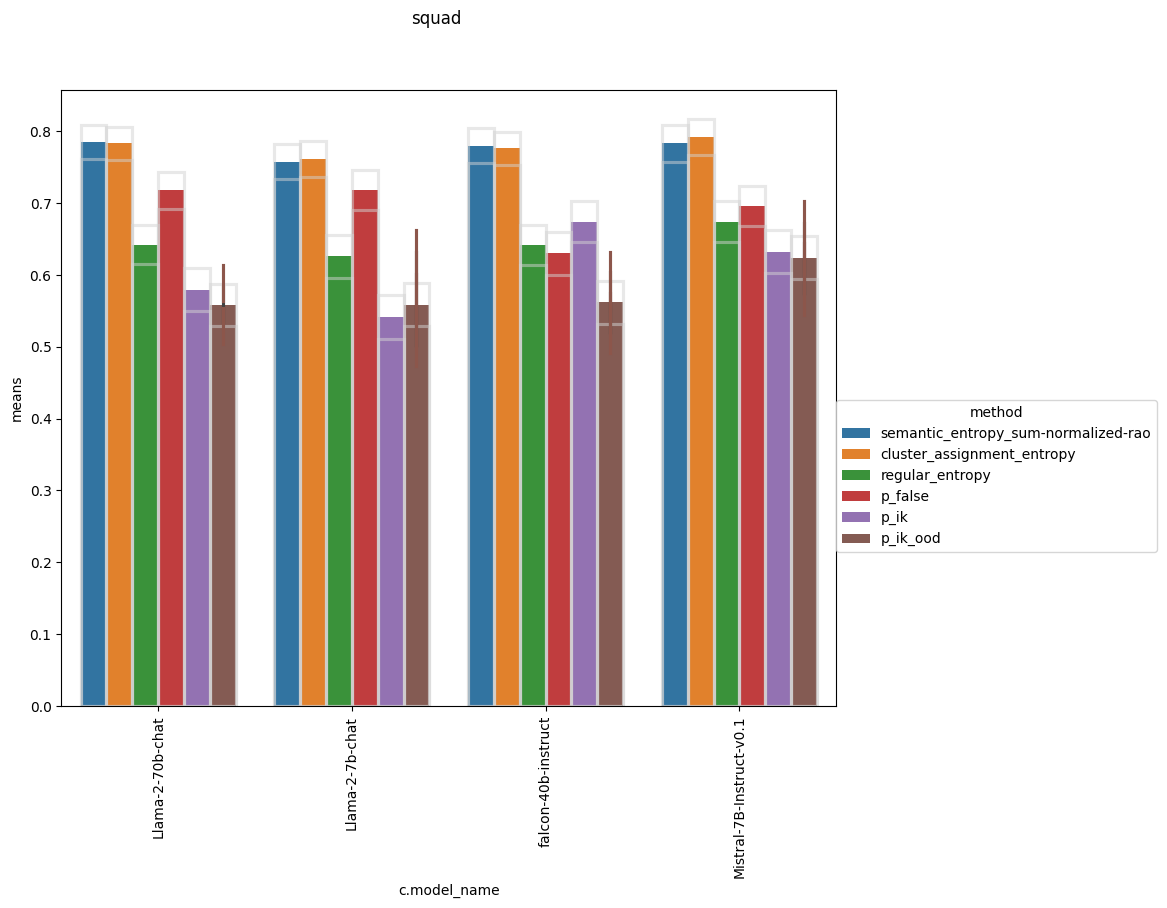

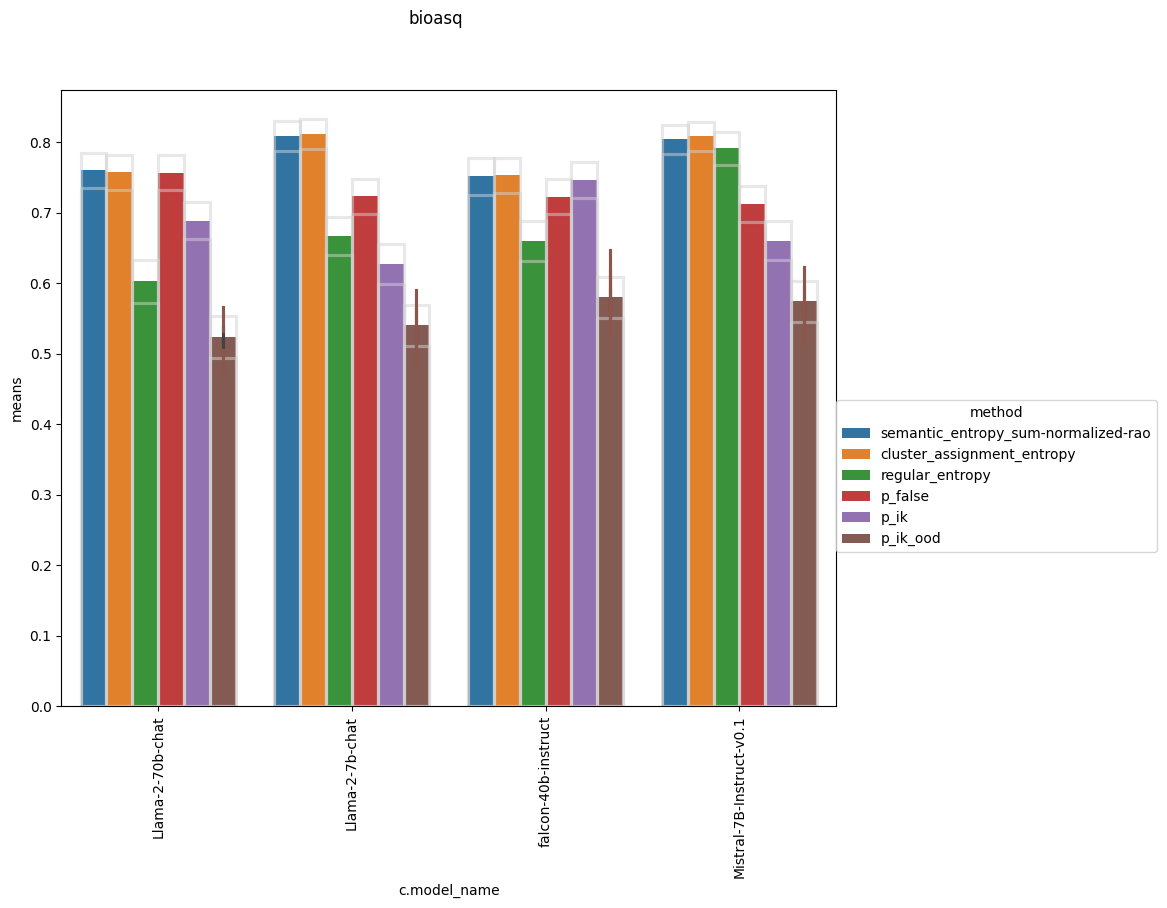

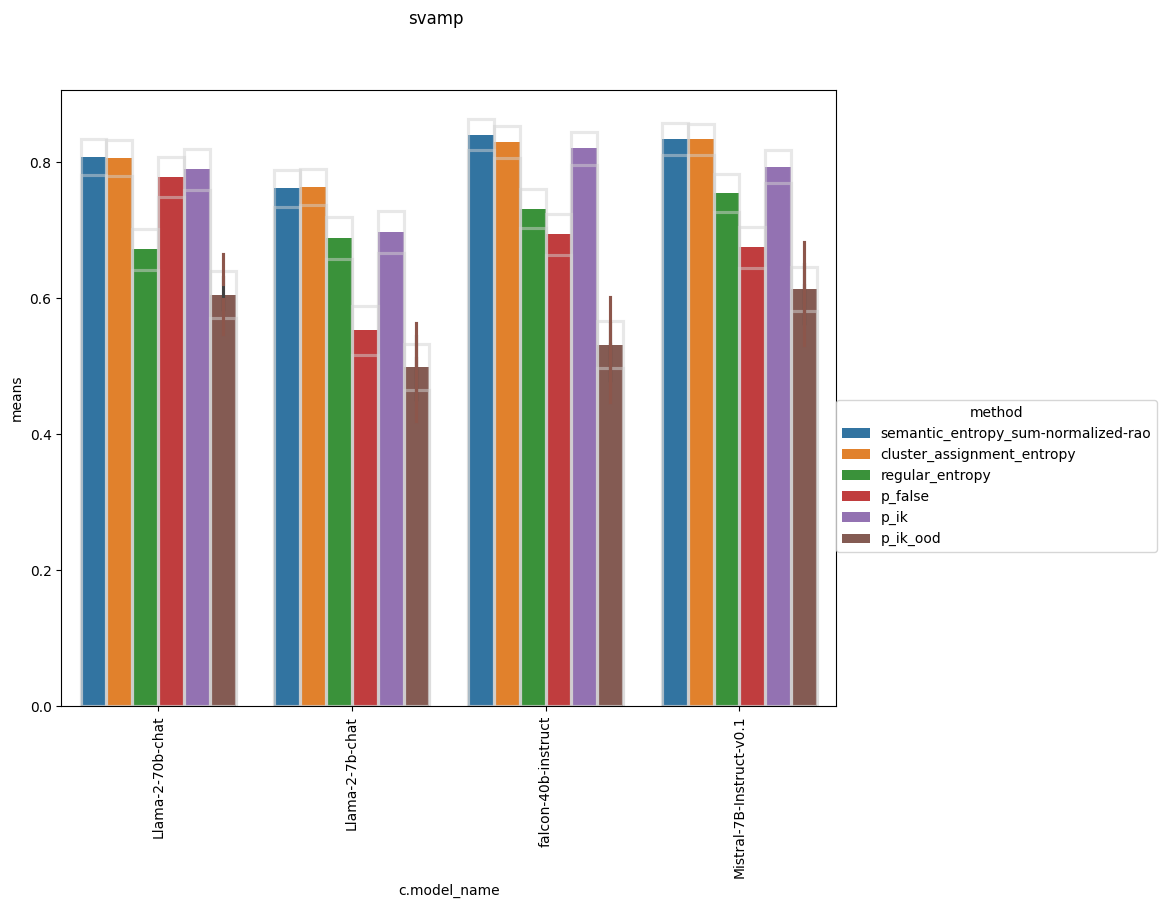

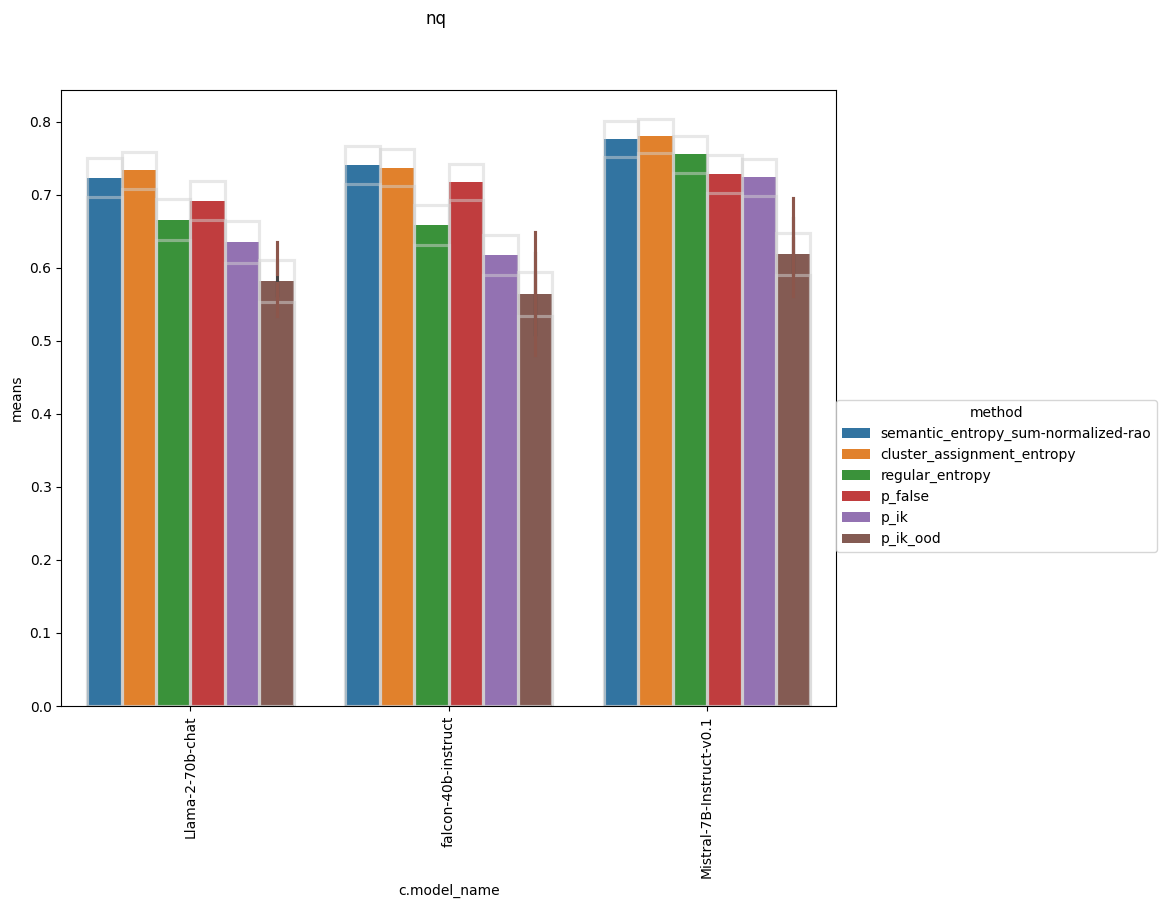

In [634]:
# restrict plot to the datasets/models currently in seb plots
for dataset in ['trivia_qa',  'squad', 'bioasq', 'svamp', 'nq']:
    if dataset == 'nq':
        models = ['Llama-2-70b-chat', 'falcon-40b-instruct', 'Mistral-7B-Instruct-v0.1']
    else:
        models = ['Llama-2-70b-chat', 'Llama-2-7b-chat', 'falcon-40b-instruct', 'Mistral-7B-Instruct-v0.1']
    gdf = cat_df.set_index('c.dataset').loc[dataset].set_index('c.model_name').loc[models].reset_index()

    methods = ['semantic_entropy_sum-normalized-rao', 'cluster_assignment_entropy', 'regular_entropy', 'p_false', 'p_ik', 'p_ik_ood']
    plot_grouped(
        gdf.set_index('metric').loc['AUROC'].set_index('method').loc[methods].reset_index(),
        metric='means', x='c.model_name', hue='method', with_sort=False)
    plt.gcf().suptitle(dataset)

/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/us

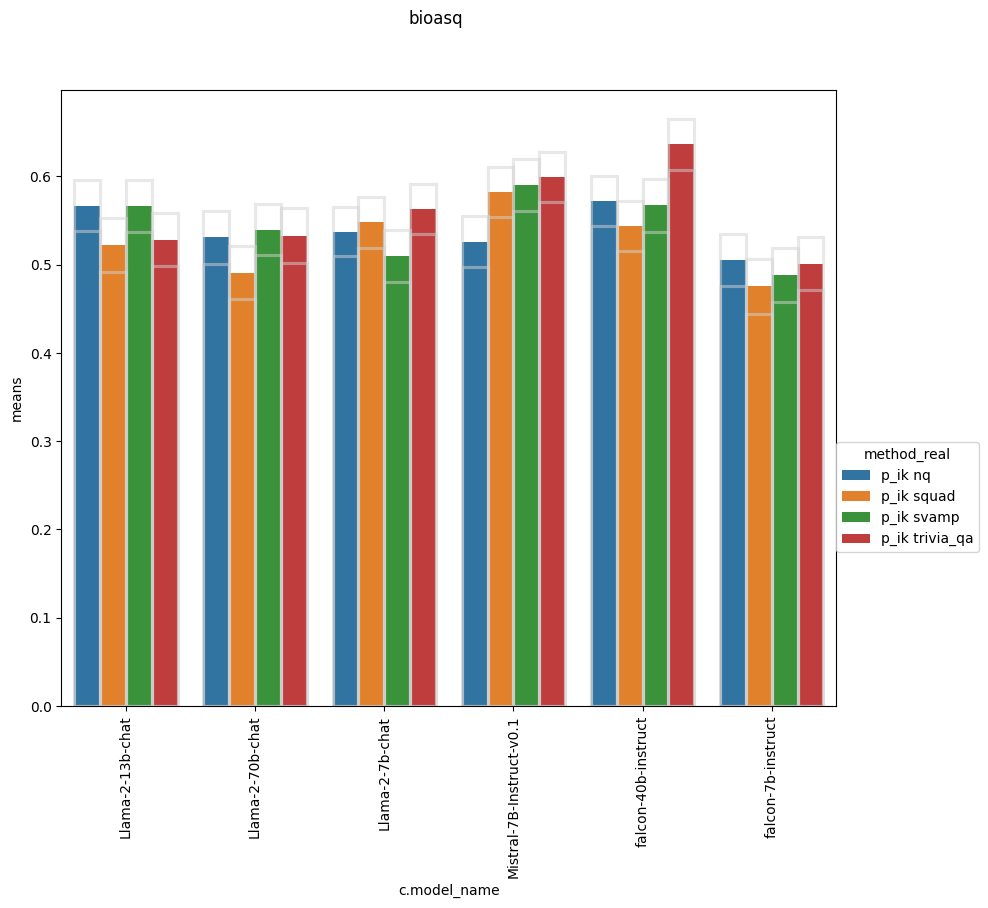

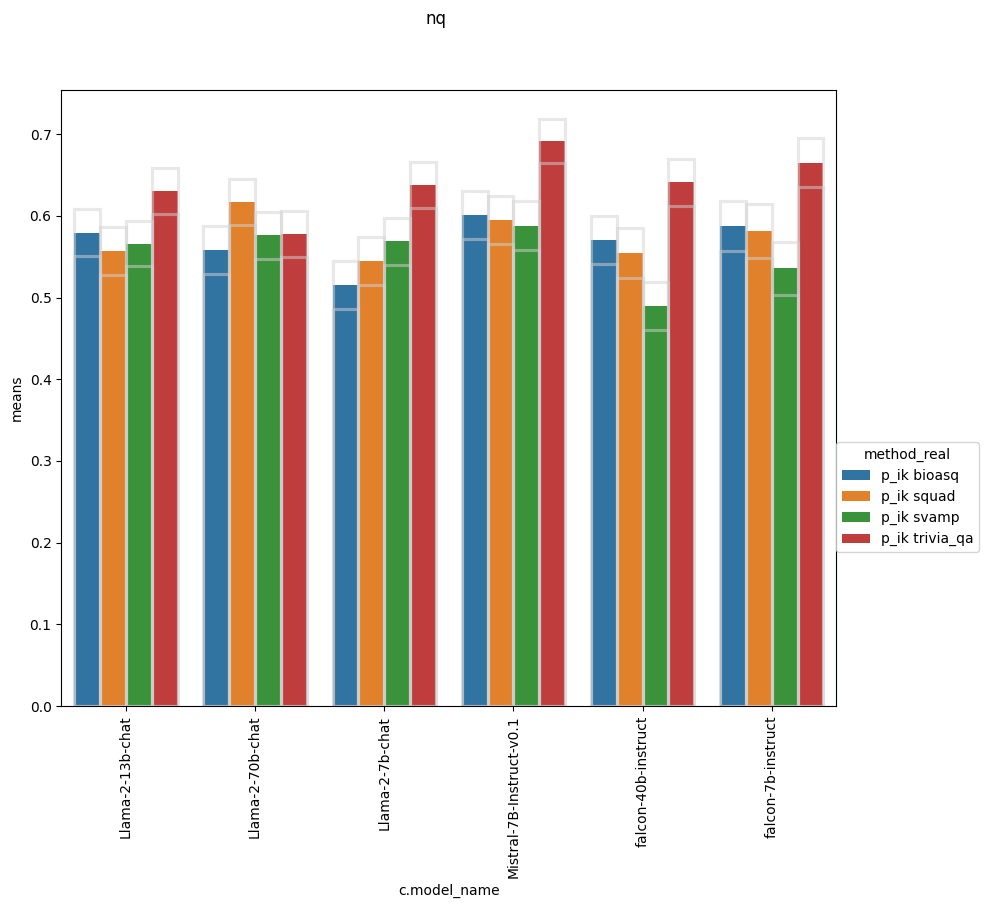

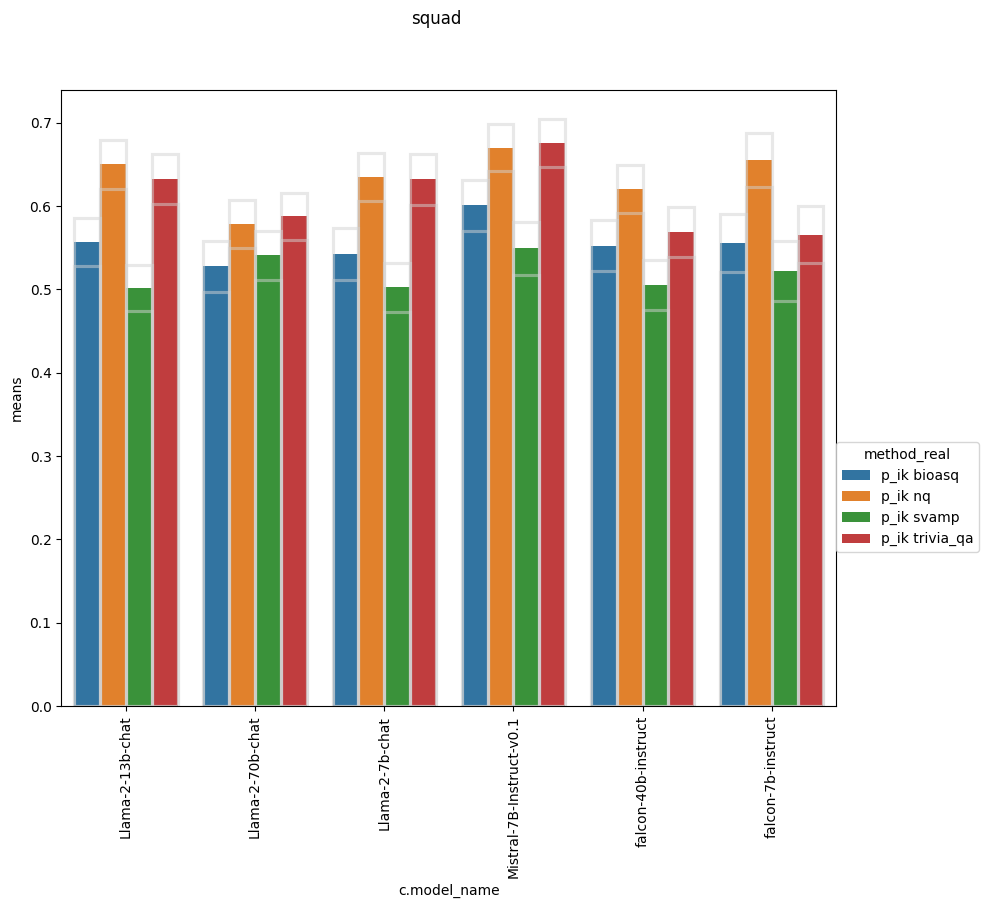

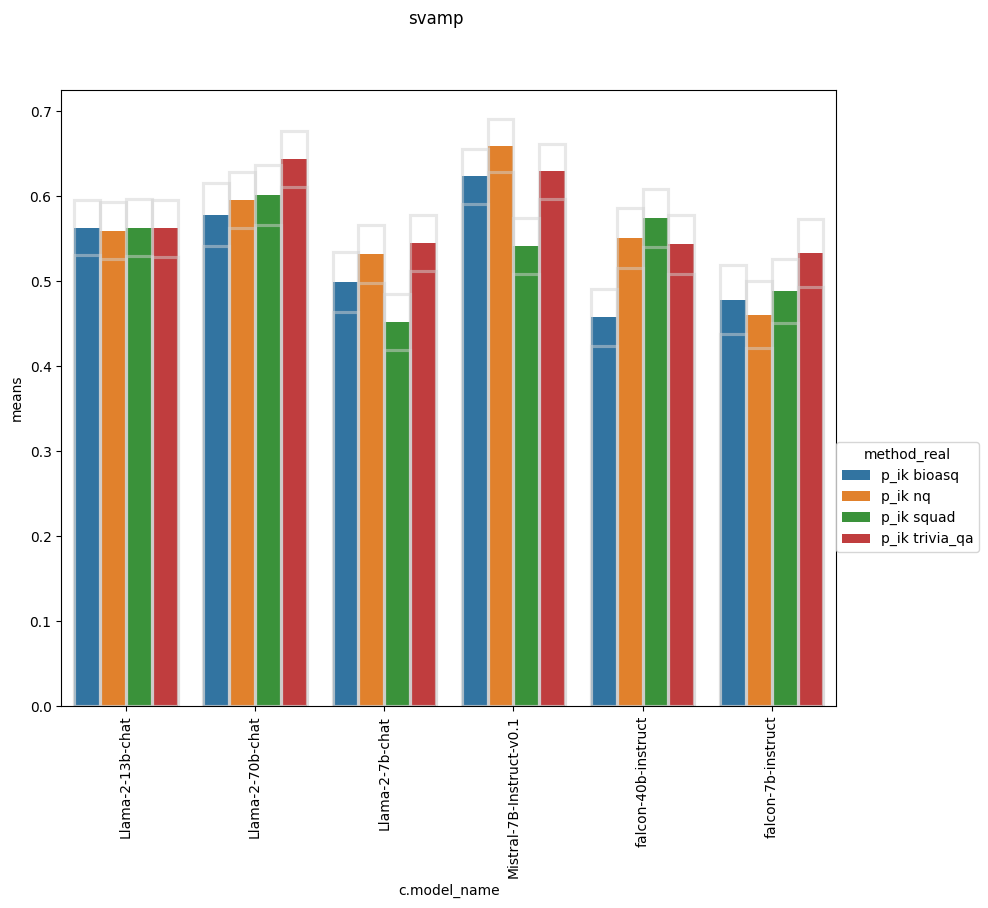

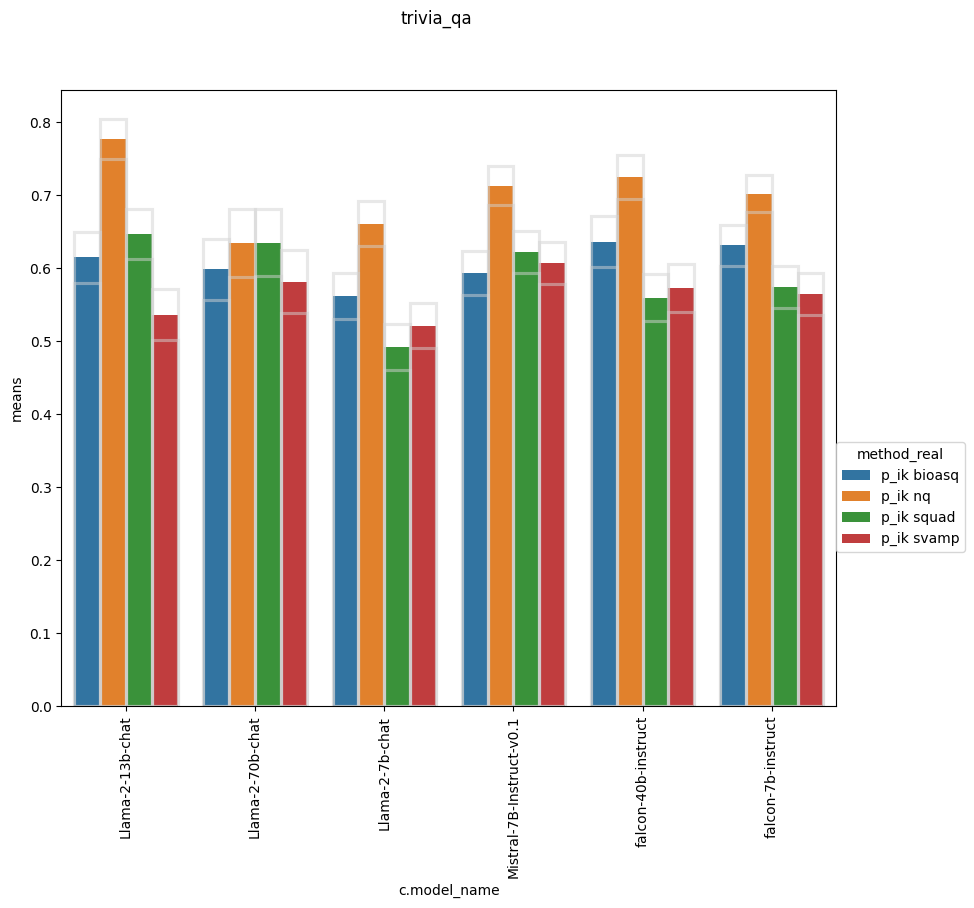

In [792]:
# ood performance separately for p_ik
for dataset, gdf in pik_all_runs.groupby('c.dataset'):
    plot_grouped(
        gdf.set_index('metric').loc['AUROC'],
        metric='means', x='c.model_name', hue='method_real',
    )
    plt.gcf().suptitle(dataset)

In [835]:
from constants import COLORS, TEXTWIDTH, GOLDEN_RATIO, METRIC_NAMES, MODEL_NAMES, PRETTY_NAMES
import matplotlib.patches as mpatches


In [1039]:
# Full Figure 2 plot for the paper
# We want a massive grid of plots that include AUROC and AU RA C for each dataset (in rows) and model (in columns)

def full_sentence_plot(df, models_in_order=[], datasets_in_order=[], methods_in_order=[], metrics_in_order=[], ylim=None, save_path=None):
    tdf = df.copy()
    n_datasets = len(datasets_in_order)
    n_models = len(models_in_order)
    fig, axs = plt.subplots(n_datasets, n_models, figsize=(2.6*TEXTWIDTH, 2*TEXTWIDTH), sharex=True, sharey='row')
    for i, dataset in enumerate(datasets_in_order):
        axs[i,0].set_ylim(bottom=1.0, top=0.0)
        
        for j, model in enumerate(models_in_order):
            gdf = tdf[(tdf['c.dataset'] == dataset) & (tdf['c.model_name'] == model) & (tdf['metric'].isin(metrics_in_order)) & (tdf['method'].isin(methods_in_order))].copy()
            
            for original_name, new_name in METRIC_NAMES.items():
                gdf.loc[gdf['metric'] == original_name,'metric'] = new_name
            if len(gdf) == 0:
                print(f"Skipping {dataset} {model}")
                continue
            ax = axs[i,j]
            g = sns.barplot(
                    x="metric",       # x variable name
                    y="means",       # y variable name
                    hue="method",  # group variable name
                    data=gdf,     # dataframe to plot
                    ax=ax,
                    hue_order = methods_in_order,
                    palette = COLORS,
                    legend = False,
                    errorbar= None,
            )

            # Min value
            temp_min = np.nanmin(gdf['means'])
            temp_max = np.nanmax(gdf['means'])
            current_min, current_max = axs[i,0].get_ylim()
            if current_min > temp_min:
                axs[i,0].set_ylim(bottom=temp_min)
            if current_max < temp_max:
                axs[i,0].set_ylim(top=temp_max)


            # Crosshatch the p_ik_ood
            n_bars = len(methods_in_order) * len(metrics_in_order)
            idxs_to_edit = np.arange(n_bars-len(metrics_in_order), n_bars, 1)
            for bar_idx, bar in enumerate(g.patches):
                if bar_idx in idxs_to_edit:
                    bar.set_hatch('//')
                    bar.set_facecolor('white')
                    bar.set_edgecolor(COLORS['p_ik_ood'])
            sns.despine()
            if i == n_datasets - 1:
                ax.set_xlabel(MODEL_NAMES[model])
            if j == 0:
                ax.set_ylabel(PRETTY_NAMES[dataset])

            ax.set_axisbelow(True)
            ax.grid(axis='y', linestyle=':', linewidth=.5)
        if ylim == None:
            current_min, current_max = axs[i,0].get_ylim()
            current_min -= 0.05
            current_max += 0.05
            ax.set_ylim(bottom=max(current_min, 0), top=min(current_max, 1.0))
        else:
            ax.set_ylim(*ylim)
    
    patches = [mpatches.Patch(color=COLORS[method], label=PRETTY_NAMES[method]) for method in methods_in_order]
    for patch in patches:
        if patch.get_label() == "Embedding Regression - OOD":
            original_edgecolor = patch.get_edgecolor()
            patch.set_hatch('//')
            patch.set_facecolor('white')
            patch.set_edgecolor(original_edgecolor)

    axs[0,2].legend(handles=patches, loc='center', bbox_to_anchor=(1.1, 1.16), ncols=3, frameon=False)
    if save_path is not None:
        plt.savefig(save_path, bbox_inches='tight', pad_inches=0.02)
    return True


    

In [932]:
entire_df = pd.concat([all_runs, pik_all_runs], axis=0).reset_index(drop=True)

In [944]:
from constants import *

True

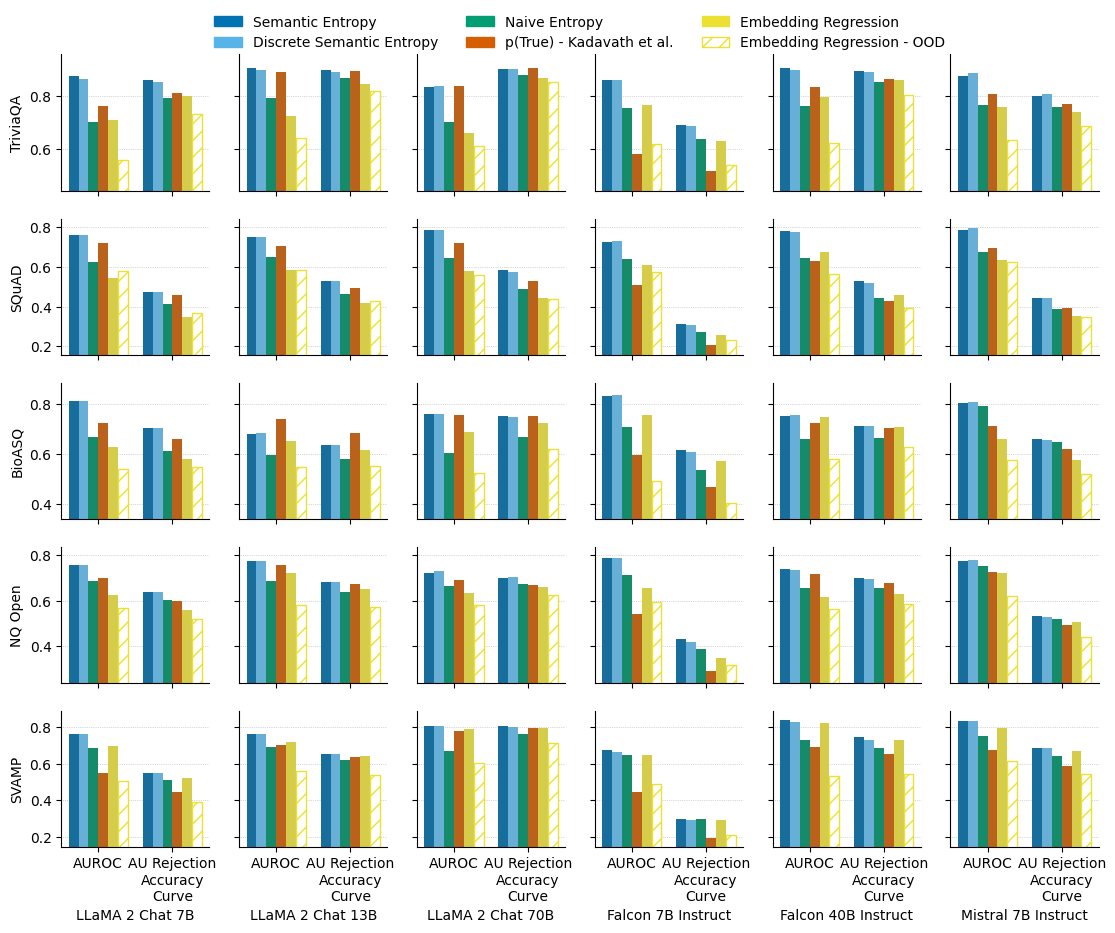

In [1042]:
# Plot for Figure 4
full_sentence_plot(entire_df,
                   datasets_in_order=['trivia_qa', 'squad', 'bioasq', 'nq', 'svamp'],
                   models_in_order=['Llama-2-7b-chat', 'Llama-2-13b-chat', 'Llama-2-70b-chat','falcon-7b-instruct', 'falcon-40b-instruct', 'Mistral-7B-Instruct-v0.1'],
                   methods_in_order = ['semantic_entropy_sum-normalized-rao', 'cluster_assignment_entropy', 'regular_entropy', 'p_false', 'p_ik', 'p_ik_ood'],
                   metrics_in_order=['AUROC', 'area_under_thresholded_accuracy'],
                   save_path="/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/final_figures/sentences_main.pdf",
                  )

True

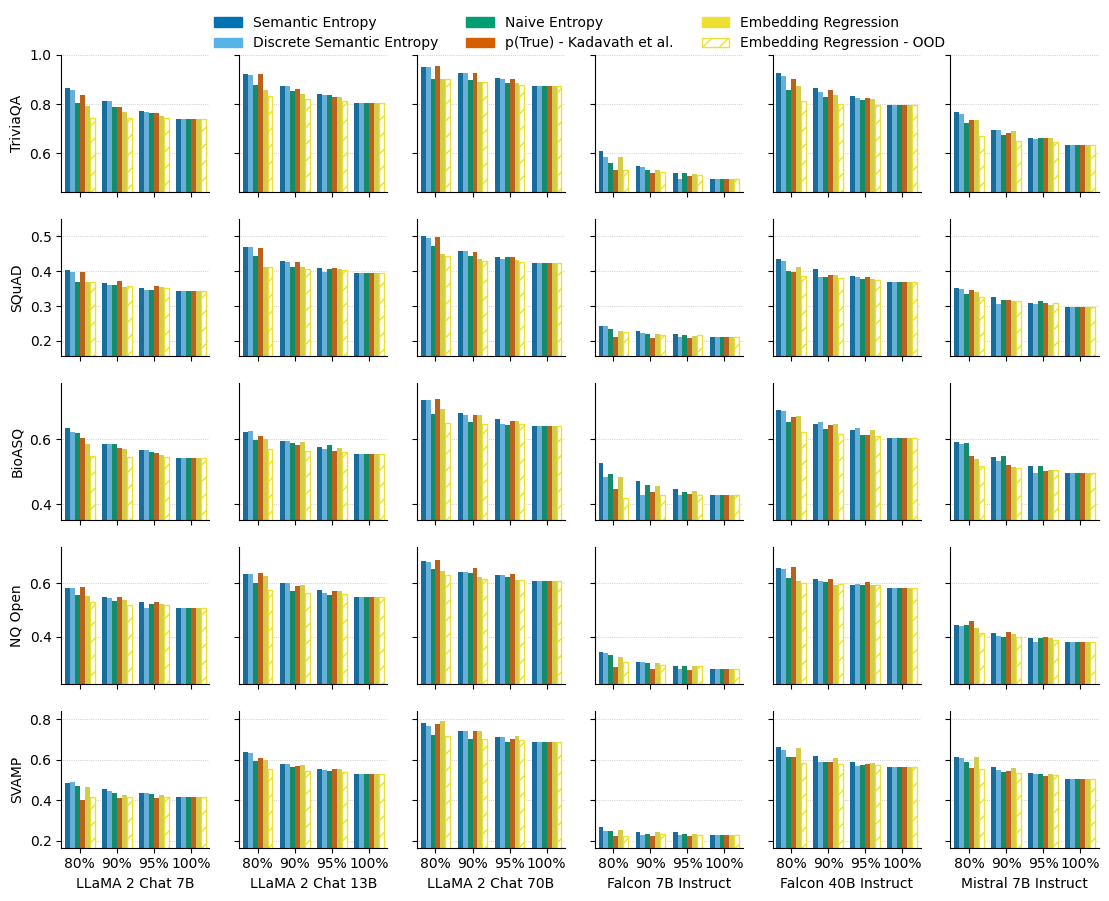

In [1043]:
# Backup plot for appendix of all the rejection accuracies

# Plot for Figure 4
full_sentence_plot(entire_df,
                   datasets_in_order=['trivia_qa', 'squad', 'bioasq', 'nq', 'svamp'],
                   models_in_order=['Llama-2-7b-chat', 'Llama-2-13b-chat', 'Llama-2-70b-chat','falcon-7b-instruct', 'falcon-40b-instruct', 'Mistral-7B-Instruct-v0.1'],
                   methods_in_order = ['semantic_entropy_sum-normalized-rao', 'cluster_assignment_entropy', 'regular_entropy', 'p_false', 'p_ik', 'p_ik_ood'],
                   metrics_in_order=['accuracy_at_0.8_answer_fraction', 'accuracy_at_0.9_answer_fraction', 'accuracy_at_0.95_answer_fraction', 'accuracy_at_1.0_answer_fraction'],
                   save_path="/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/final_figures/app_sentences_rejection_accuracy.pdf")

In [ ]:
def sort_dataframe_by_custom_order(df, column, order):
    """
    Sorts a copy of a DataFrame along a specified column by a specified order of keys.

    Parameters:
    df (pandas.DataFrame): The DataFrame to sort.
    column (str): The column name along which to sort.
    order (list): The specific order of keys for sorting.

    Returns:
    pandas.DataFrame: A sorted copy of the original DataFrame.
    """
    # Create a copy of the DataFrame to avoid modifying the original
    df_copy = df.copy()

    # Create a mapping of the order values to their index
    order_mapping = {key: i for i, key in enumerate(order)}

    # Assign a high number for keys not included in the order to sort them at the end
    max_index = len(order)
    df_copy['sort_order'] = df_copy[column].map(lambda x: order_mapping.get(x, max_index))

    # Sort the DataFrame copy by the temporary 'sort_order' column
    sorted_df = df_copy.sort_values('sort_order').drop('sort_order', axis=1)

    return sorted_df


plot the same, but per dataset

(actually, semantic entropy (and variants), are not that bad overall, especially once you start taking smaller models into account (where e.g. p_false oftens sucks))

In [934]:
# note that instead of low/high, should probably compute the standard error over the mean here! (if there are enough categories that we average over!)

tmp = all_runs.set_index('metric').loc['AUROC']

# select main runs (they have deberta entailment and squad metric)
tmp = tmp.set_index('method').loc['semantic_entropy_sum-normalized-rao']
tmp.groupby('c.model_name').mean('means').sort_values('means', ascending=False)

,means,low,high
c.model_name,,,
Mistral-7B-Instruct-v0.1,0.814450,0.791561,0.837339
falcon-40b-instruct,0.803653,0.779970,0.827337
Llama-2-7b-chat,0.792238,0.768770,0.815705
Llama-2-70b-chat,0.781684,0.754098,0.809270
falcon-7b-instruct,0.775545,0.749529,0.801561
Llama-2-13b-chat,0.774681,0.750719,0.798642


In [936]:
# note that instead of low/high, should probably compute the standard error over the mean here! (if there are enough categories that we average over!)

tmp = all_runs.set_index('metric').loc['AUROC']

# select main runs (they have deberta entailment and squad metric)
tmp = tmp.set_index('method').loc['p_false']
tmp.groupby('c.model_name').mean('means').sort_values('means', ascending=False)

,means,low,high
c.model_name,,,
Llama-2-13b-chat,0.759667,0.734858,0.784476
Llama-2-70b-chat,0.756519,0.728657,0.784382
Mistral-7B-Instruct-v0.1,0.723570,0.697003,0.750137
falcon-40b-instruct,0.719835,0.692125,0.747546
Llama-2-7b-chat,0.691225,0.662331,0.720119
falcon-7b-instruct,0.534574,0.501596,0.567552


In [937]:
# note that instead of low/high, should probably compute the standard error over the mean here! (if there are enough categories that we average over!)
tmp = all_runs.set_index('metric').loc['AUROC']
# select main runs (they have deberta entailment and squad metric)
tmp = tmp.set_index('method').loc['p_ik']
tmp.groupby('c.model_name').mean('means').sort_values('means', ascending=False)

,means,low,high
c.model_name,,,
falcon-40b-instruct,0.730991,0.704272,0.757709
Mistral-7B-Instruct-v0.1,0.713585,0.687219,0.739951
falcon-7b-instruct,0.685599,0.655044,0.716154
Llama-2-13b-chat,0.679763,0.651341,0.708185
Llama-2-70b-chat,0.670703,0.639730,0.701675
Llama-2-7b-chat,0.639679,0.609948,0.669410


In [941]:
# note that instead of low/high, should probably compute the standard error over the mean here! (if there are enough categories that we average over!)
tmp = all_runs.set_index('metric').loc['AUROC']
# select main runs (they have deberta entailment and squad metric)
tmp = tmp.set_index('method').loc['regular_entropy']
tmp.groupby('c.model_name').mean('means').sort_values('means', ascending=False)

,means,low,high
c.model_name,,,
Mistral-7B-Instruct-v0.1,0.748467,0.722987,0.773948
falcon-7b-instruct,0.691972,0.661023,0.722921
falcon-40b-instruct,0.690869,0.662557,0.719180
Llama-2-13b-chat,0.683719,0.654627,0.712811
Llama-2-7b-chat,0.674263,0.645500,0.703026
Llama-2-70b-chat,0.657328,0.626119,0.688537


In [403]:
# note that instead of low/high, should probably compute the standard error over the mean here! (if there are enough categories that we average over!)

tmp = all_runs.set_index('metric').loc['AUROC']

# select main runs (they have deberta entailment and squad metric)
tmp = tmp.set_index('method').loc['semantic_entropy_sum-normalized-rao']
tmp.groupby('c.dataset').mean('means').sort_values('means', ascending=False)

,means,low,high
c.dataset,,,
trivia_qa,0.872292,0.848631,0.895952
svamp,0.810605,0.785411,0.835799
bioasq,0.781628,0.758371,0.804886
squad,0.776370,0.751841,0.800900
nq,0.731898,0.705572,0.758225


In [935]:
# note that instead of low/high, should probably compute the standard error over the mean here! (if there are enough categories that we average over!)
main_methods = [
    'semantic_entropy_sum-normalized-rao',
    'cluster_assignment_entropy',
    'regular_entropy',
    'p_false',
    'p_ik',
]

tmp = all_runs.set_index('metric').loc['AUROC']
# select main runs (they have deberta entailment and squad metric)
# tmp = tmp[tmp.method.map(lambda x: 'UNANSWERABLE' not in x)]
tmp = tmp.set_index('method').loc[main_methods].reset_index()[['method', 'means']]
means = tmp.groupby('method').mean('means').sort_values('means', ascending=False).loc[main_methods]
sems = tmp.groupby('method').agg(sem).sort_values('means', ascending=False).loc[main_methods].rename(columns={'means': 'sem'})
perfstmp = pd.concat([means, sems], axis=1)
with pd.option_context('display.precision', 3):
    display(perfstmp)

,means,sem
method,,
semantic_entropy_sum-normalized-rao,0.790,0.011
cluster_assignment_entropy,0.791,0.011
regular_entropy,0.691,0.010
p_false,0.698,0.018
p_ik,0.687,0.013


In [828]:
print(len(all_runs.groupby(['c.model_name', 'c.dataset'])))

for group, tmp in all_runs.groupby(['c.model_name', 'c.dataset']):
    print(group)

30
('Llama-2-13b-chat', 'bioasq')
('Llama-2-13b-chat', 'nq')
('Llama-2-13b-chat', 'squad')
('Llama-2-13b-chat', 'svamp')
('Llama-2-13b-chat', 'trivia_qa')
('Llama-2-70b-chat', 'bioasq')
('Llama-2-70b-chat', 'nq')
('Llama-2-70b-chat', 'squad')
('Llama-2-70b-chat', 'svamp')
('Llama-2-70b-chat', 'trivia_qa')
('Llama-2-7b-chat', 'bioasq')
('Llama-2-7b-chat', 'nq')
('Llama-2-7b-chat', 'squad')
('Llama-2-7b-chat', 'svamp')
('Llama-2-7b-chat', 'trivia_qa')
('Mistral-7B-Instruct-v0.1', 'bioasq')
('Mistral-7B-Instruct-v0.1', 'nq')
('Mistral-7B-Instruct-v0.1', 'squad')
('Mistral-7B-Instruct-v0.1', 'svamp')
('Mistral-7B-Instruct-v0.1', 'trivia_qa')
('falcon-40b-instruct', 'bioasq')
('falcon-40b-instruct', 'nq')
('falcon-40b-instruct', 'squad')
('falcon-40b-instruct', 'svamp')
('falcon-40b-instruct', 'trivia_qa')
('falcon-7b-instruct', 'bioasq')
('falcon-7b-instruct', 'nq')
('falcon-7b-instruct', 'squad')
('falcon-7b-instruct', 'svamp')
('falcon-7b-instruct', 'trivia_qa')


,means,sem
method,,
semantic_entropy_sum-normalized-rao,0.790,0.011
cluster_assignment_entropy,0.791,0.011
regular_entropy,0.691,0.010
p_false,0.698,0.018
p_ik,0.687,0.013


# Analyze length of generations

In [730]:
# read generations from run
# all_gens = {}
for wandb_id in runs:
    if wandb_id not in all_gens:
        if eval := configs[wandb_id].get('eval_wandb_runid'):
            # I split up compute_uncertainty for some runs to free up gpus.
            print(f'Taking generate_answers from {eval} instead of compute_uncertainty cfg for {wandb_id}')
            wandb_id = eval
    
        all_gens[wandb_id] = restore_file(wandb_id, filenames=['validation_generations.pkl'])

In [731]:
low_temp, high_temp, df = get_length_statistic(all_gens)
df = df.merge(arg_df[['wandbid', 'c.dataset', 'c.model_name']], on='wandbid')

df

,temp,wandbid,statistic,value,c.dataset,c.model_name
0,low,grar15m5,mean,153.432500,bioasq,Llama-2-7b-chat
1,low,grar15m5,sem,3.247561,bioasq,Llama-2-7b-chat
2,low,grar15m5,std,64.869989,bioasq,Llama-2-7b-chat
3,low,grar15m5,median,151.500000,bioasq,Llama-2-7b-chat
4,high,grar15m5,mean,155.682250,bioasq,Llama-2-7b-chat
...,...,...,...,...,...,...
235,low,spgwcck1,median,103.500000,nq,Llama-2-13b-chat
236,high,spgwcck1,mean,119.711500,nq,Llama-2-13b-chat
237,high,spgwcck1,sem,1.013929,nq,Llama-2-13b-chat
238,high,spgwcck1,std,64.118494,nq,Llama-2-13b-chat


In [732]:
np.concatenate(list(low_temp.values()) + list(high_temp.values())).shape

(134200,)

In [733]:
stats(np.concatenate(list(low_temp.values()) + list(high_temp.values())))

{'mean': 95.62643070044709,
 'sem': 0.18995454041836543,
 'std': 69.58639190087176,
 'median': 80.0}

In [734]:
# this is only correct for mean!!
# stats(df.set_index('statistic').loc['mean']['value'])

In [742]:
# easy check if we have af ull set of results
df.set_index('temp').loc['low'].set_index('statistic').loc['mean'].pivot(index='c.dataset', columns='c.model_name', values='value')

c.model_name,Llama-2-13b-chat,Llama-2-70b-chat,Llama-2-7b-chat,Mistral-7B-Instruct-v0.1,falcon-40b-instruct,falcon-7b-instruct
c.dataset,,,,,,
bioasq,160.8325,167.540000,153.432500,92.735000,101.8650,95.010
nq,118.4175,115.350000,121.800000,71.645000,71.7725,63.650
squad,134.7200,131.115000,122.955000,80.790000,90.2400,73.875
svamp,61.3200,57.666667,60.203333,32.263333,45.1300,45.440
trivia_qa,78.3450,72.365000,65.932500,35.060000,51.4100,45.770


In [735]:
# more_detailed results per model and dataset
for name, gdf in df.groupby('temp'):
    print('temperature', name)
    display(gdf.pivot(index=['c.dataset', 'c.model_name'], columns='statistic', values='value')) 

temperature high


statistic                                 mean  median       sem        std
c.dataset c.model_name                                                     
bioasq    Llama-2-13b-chat          162.567250   162.0  1.154380  73.000298
          Llama-2-70b-chat          167.595500   164.0  1.261260  79.759096
          Llama-2-7b-chat           155.682250   154.0  1.056253  66.794942
          Mistral-7B-Instruct-v0.1  102.202250    96.0  0.983591  62.199951
          falcon-40b-instruct       124.064750   114.0  1.096878  69.363997
          falcon-7b-instruct        103.792000    99.0  0.856930  54.190264
nq        Llama-2-13b-chat          119.711500   103.0  1.013929  64.118494
          Llama-2-70b-chat          115.794750   102.0  0.994312  62.877938
          Llama-2-7b-chat           122.772500   110.0  0.965781  61.073720
          Mistral-7B-Instruct-v0.1   72.718500    65.0  0.853062  53.945614
          falcon-40b-instruct        82.637250    72.0  0.887460  56.120902
          falcon-7b-instruct         67.137500    61.0  0.814854  51.529463
squad     Llama-2-13b-chat          136.083750   118.0  1.184342  74.895015
          Llama-2-70b-chat          132.881500   114.0  1.237496  78.256351
          Llama-2-7b-chat           123.541000   110.0  1.090283  68.946920
          Mistral-7B-Instruct-v0.1   83.490250    74.0  0.985835  62.341887
          falcon-40b-instruct       102.342500    90.0  1.060311  67.051553
          falcon-7b-instruct         80.702500    74.0  0.861105  54.454265
svamp     Llama-2-13b-chat           62.290333    54.0  0.644564  35.298357
          Llama-2-70b-chat           61.252667    52.0  0.692701  37.934454
          Llama-2-7b-chat            59.152667    49.0  0.653455  35.785249
          Mistral-7B-Instruct-v0.1   35.697000    33.0  0.531858  29.126206
          falcon-40b-instruct        54.428000    43.0  0.915392  50.129720
          falcon-7b-instruct         47.472333    40.0  0.689405  37.753965
trivia_qa Llama-2-13b-chat           79.825000    73.0  0.712429  45.052318
          Llama-2-70b-chat           74.781750    67.0  0.757484  47.901510
          Llama-2-7b-chat            67.093000    61.0  0.713263  45.105076
          Mistral-7B-Instruct-v0.1   38.353250    18.0  0.642521  40.631527
          falcon-40b-instruct        53.685750    47.0  0.718930  45.463447
          falcon-7b-instruct         48.560250    38.0  0.672567  42.531551

temperature low


statistic                                 mean  median       sem        std
c.dataset c.model_name                                                     
bioasq    Llama-2-13b-chat          160.832500   160.5  3.520073  70.313402
          Llama-2-70b-chat          167.540000   163.5  3.865991  77.223108
          Llama-2-7b-chat           153.432500   151.5  3.247561  64.869989
          Mistral-7B-Instruct-v0.1   92.735000    83.5  2.592427  51.783683
          falcon-40b-instruct       101.865000    95.0  2.316767  46.277389
          falcon-7b-instruct         95.010000    90.0  2.136302  42.672590
nq        Llama-2-13b-chat          118.417500   103.5  3.150016  62.921524
          Llama-2-70b-chat          115.350000   101.0  3.114978  62.221640
          Llama-2-7b-chat           121.800000   108.0  2.990622  59.737635
          Mistral-7B-Instruct-v0.1   71.645000    65.0  2.313437  46.210864
          falcon-40b-instruct        71.772500    68.0  1.717750  34.312035
          falcon-7b-instruct         63.650000    59.0  2.268335  45.309960
squad     Llama-2-13b-chat          134.720000   118.5  3.750312  74.912426
          Llama-2-70b-chat          131.115000   111.0  3.759661  75.099180
          Llama-2-7b-chat           122.955000   110.0  3.443627  68.786394
          Mistral-7B-Instruct-v0.1   80.790000    74.0  2.714514  54.222375
          falcon-40b-instruct        90.240000    82.0  2.377032  47.481179
          falcon-7b-instruct         73.875000    69.5  2.376522  47.470985
svamp     Llama-2-13b-chat           61.320000    52.0  2.068388  35.765779
          Llama-2-70b-chat           57.666667    49.0  1.869978  32.334948
          Llama-2-7b-chat            60.203333    50.0  2.057432  35.576331
          Mistral-7B-Instruct-v0.1   32.263333    31.5  1.177285  20.357161
          falcon-40b-instruct        45.130000    40.0  1.601629  27.694761
          falcon-7b-instruct         45.440000    38.0  1.795187  31.041688
trivia_qa Llama-2-13b-chat           78.345000    71.5  2.174353  43.432660
          Llama-2-70b-chat           72.365000    64.0  2.255123  45.046052
          Llama-2-7b-chat            65.932500    61.0  2.124421  42.435279
          Mistral-7B-Instruct-v0.1   35.060000    16.0  1.859745  37.148370
          falcon-40b-instruct        51.410000    49.0  1.940904  38.769536
          falcon-7b-instruct         45.770000    37.0  1.857986  37.113233

In [743]:
# average length per dataset
for name, gdf in df.groupby('temp'):
    print('temperature', name)
    gdf = gdf.set_index('statistic').loc['mean'].reset_index()
    display(gdf.groupby('c.dataset').mean('value'))


temperature high


,value
c.dataset,
bioasq,135.984000
nq,96.795333
squad,109.840250
svamp,53.382167
trivia_qa,60.383167


temperature low


,value
c.dataset,
bioasq,128.569167
nq,93.772500
squad,105.615833
svamp,50.337222
trivia_qa,58.147083


In [744]:
# average length per model
for name, gdf in df.groupby('temp'):
    print(name)
    gdf = gdf.set_index('statistic').loc['mean']
    display(gdf.groupby('c.model_name').mean('value'))

high


,value
c.model_name,
Llama-2-13b-chat,112.095567
Llama-2-70b-chat,110.461233
Llama-2-7b-chat,105.648283
Mistral-7B-Instruct-v0.1,66.492250
falcon-40b-instruct,83.431650
falcon-7b-instruct,69.532917


low


,value
c.model_name,
Llama-2-13b-chat,110.727000
Llama-2-70b-chat,108.807333
Llama-2-7b-chat,104.864667
Mistral-7B-Instruct-v0.1,62.498667
falcon-40b-instruct,72.083500
falcon-7b-instruct,64.749000


# Cluster distribution 

In [747]:
# uncertainties = {}
for wandb_id in runs:
    if wandb_id not in uncertainties:
        uncertainties[wandb_id] = restore_file(wandb_id, filenames=['uncertainty_measures.pkl'])

In [748]:
num_ids = {}
for wandbid, unc in uncertainties.items():
    unc = unc[0]
    num_ids[wandbid] = np.array([len(np.unique(s)) for s in np.array(unc['semantic_ids'])])

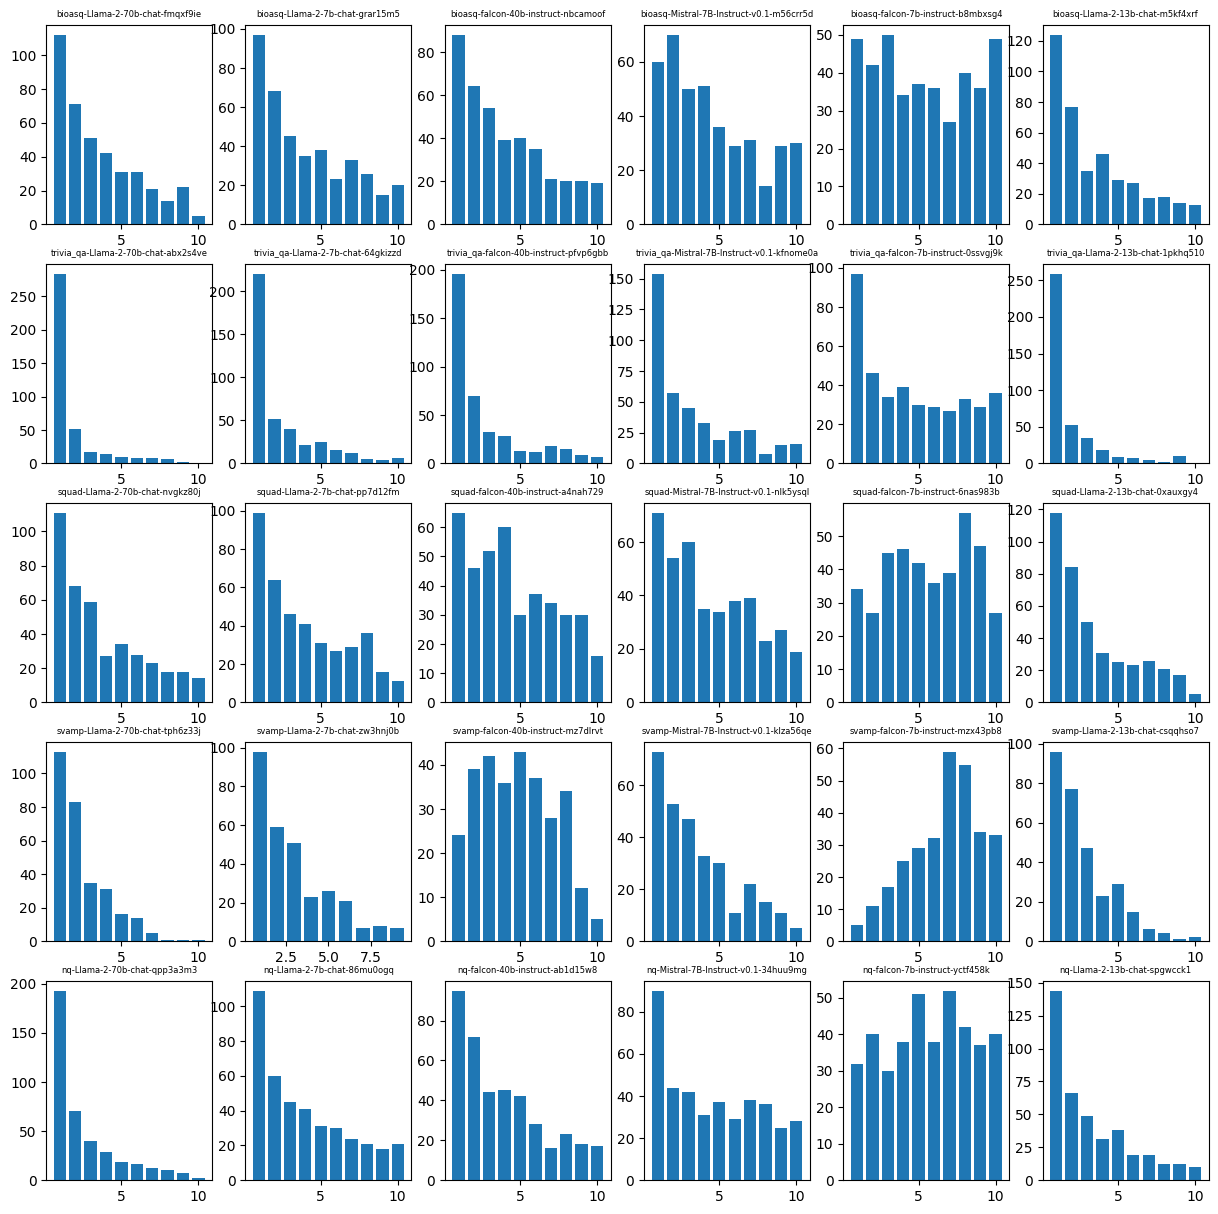

In [750]:
fig, axes_2d = plt.subplots(*arg_df[['c.dataset', 'c.model_name']].nunique().values, figsize=(15, 15))

for axes, dataset in zip(axes_2d, arg_df['c.dataset'].unique()):
    for ax, model in zip(axes, arg_df['c.model_name'].unique()):
        try:
            wid = arg_df.set_index('c.dataset').loc[dataset].set_index('c.model_name').loc[model]['wandbid']
            ax.set_title(f'{dataset}-{model}-{wid}', fontsize=6)
            uniq_counts, count_values = np.unique(num_ids[wid], return_counts=True)
            ax.bar(uniq_counts, count_values)
        except Exception as e:
            print(e)
            ax.set_title(f'{dataset}-{model}-FAIL', fontsize=6)
    


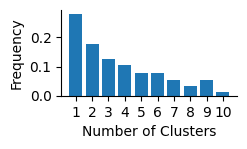

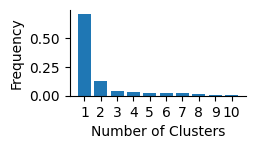

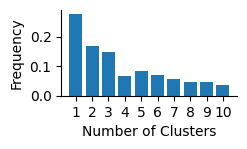

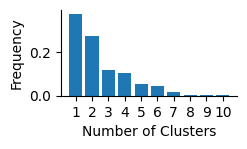

In [544]:
def plot_clusters(model, dataset, save_path=None):
    fig, ax = plt.subplots(1,1,figsize=(TEXTWIDTH / 2, TEXTWIDTH / 2 / GOLDEN_RATIO))
    wid = arg_df.set_index('c.dataset').loc[dataset].set_index('c.model_name').loc[model]['wandbid']
    uniq_counts, count_values = np.unique(num_ids[wid], return_counts=True)
    cluster_frequencies = count_values / sum(count_values)
    ax.bar(uniq_counts, cluster_frequencies)
    ax.set_xticks(uniq_counts)
    ax.set_xlabel('Number of Clusters')
    ax.set_ylabel('Frequency')
    sns.despine()
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)

for dataset in ["bioasq", "trivia_qa", "squad","svamp"]:
    plot_clusters('Llama-2-70b-chat', dataset, save_path=f"/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/final_figures/app_sentences_n_clusters_{dataset}.pdf")

In [751]:
cdf = get_cluster_stats(num_ids)
cdf = cdf.merge(arg_df[['wandbid', 'c.dataset', 'c.model_name']], on='wandbid')

cdf

,wandbid,statistic,value,c.dataset,c.model_name
0,fmqxf9ie,mean,3.557500,bioasq,Llama-2-70b-chat
1,fmqxf9ie,sem,0.126716,bioasq,Llama-2-70b-chat
2,fmqxf9ie,std,2.531145,bioasq,Llama-2-70b-chat
3,fmqxf9ie,median,3.000000,bioasq,Llama-2-70b-chat
4,grar15m5,mean,4.025000,bioasq,Llama-2-7b-chat
...,...,...,...,...,...
115,yctf458k,median,6.000000,nq,falcon-7b-instruct
116,spgwcck1,mean,3.220000,nq,Llama-2-13b-chat
117,spgwcck1,sem,0.125223,nq,Llama-2-13b-chat
118,spgwcck1,std,2.501320,nq,Llama-2-13b-chat


In [752]:
# overall stats
stats(np.concatenate(list(num_ids.values())))

{'mean': 3.820701754385965,
 'sem': 0.026109024787841974,
 'std': 2.7875587380478817,
 'median': 3.0}

In [753]:
display(cdf.set_index('statistic').loc['mean'].groupby('c.model_name').mean('value'))

,value
c.model_name,
Llama-2-13b-chat,2.968833
Llama-2-70b-chat,2.805833
Llama-2-7b-chat,3.462833
Mistral-7B-Instruct-v0.1,4.109833
falcon-40b-instruct,4.001167
falcon-7b-instruct,5.592500


In [754]:
display(cdf.set_index('statistic').loc['mean'].groupby('c.dataset').mean('value'))

,value
c.dataset,
bioasq,4.161667
nq,3.977917
squad,4.299583
svamp,3.876667
trivia_qa,2.801667


# Create run scripts for p_ik ood eval

In [778]:
cmd = 'sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py '
cmd += '--eval_wandb_runid={eval} --train_wandb_runid={train} --no-compute_predictive_entropy --experiment_lot=231202_ptrue_ood'

In [779]:
targets = ['Llama-2-7b-chat']
for model, gdf in arg_df.groupby('c.model_name'):
    print(f'# model: {model}')
    if model not in targets:
        continue
    for ds1, gdf1 in gdf.groupby('c.dataset'):
        assert len(gdf1) == 1
        for ds2, gdf2 in gdf.groupby('c.dataset'):
            assert len(gdf2) == 1

            if ds1 == ds2:
                continue

            if (ds1 == 'nq') or (ds2 == 'nq'):
    
                wandbid1 = gdf1['wandbid'].values[0]
                wandbid2 = gdf2['wandbid'].values[0]
                
                print(cmd.format(eval=wandbid1, train=wandbid2) + f' # {ds1}, {ds2}')

# model: Llama-2-13b-chat
# model: Llama-2-70b-chat
# model: Llama-2-7b-chat
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --eval_wandb_runid=grar15m5 --train_wandb_runid=86mu0ogq --no-compute_predictive_entropy --experiment_lot=231202_ptrue_ood # bioasq, nq
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --eval_wandb_runid=86mu0ogq --train_wandb_runid=grar15m5 --no-compute_predictive_entropy --experiment_lot=231202_ptrue_ood # nq, bioasq
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --eval_wandb_runid=86mu0ogq --train_wandb_runid=pp7d12fm --no-compute_predictive_entropy --experiment_lot=231202_ptrue_ood # nq, squad
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --eval_wandb_runid=86mu0ogq --train_

# Check on p_ik ood runs

In [780]:
import wandb

api = wandb.Api()
api_runs = api.runs('goatml/semantic_uncertainty')


In [781]:
configs = {}
for run in api_runs[:100]:
    finished = run.state == 'finished'
    lot = run.description.endswith('231202_ptrue_ood')
    if lot and finished:
        configs[run.id] = run.config
        configs[run.id]['state'] = run.state
        configs[run.id]['slurmid'] = run.notes.split(': ')[1].split(',')[0]


In [782]:
args = ['state', 'slurmid', 'dataset', 'model_name', 'ood_training_set', 'train_wandb_runid', 'eval_wandb_runid']
# args = ['state', 'slurmid', 'dataset', 'train_wandb_runid', 'eval_wandb_runid']

tmp_arg_df, _, _ = get_arg_df(configs)

tmp_arg_df['c.model_name'] = tmp_arg_df['c.model_name'].map(lambda x: x if not x.endswith('-8bit') else x[:-len('-8bit')])

with pd.option_context('display.max_rows', None):
    tmp = tmp_arg_df
    display(tmp.set_index('c.state').loc['finished']) #need display to show the dataframe when using with in jupyter


,wandbid,c.slurmid,c.dataset,c.model_name,c.ood_training_set,c.train_wandb_runid,c.eval_wandb_runid,UNIQ-c.dataset-c.model_name-c.ood_training_set-c.train_wandb_runid-c.eval_wandb_runid
c.state,,,,,,,,
finished,uli0h53r,173306,svamp,Llama-2-7b-chat,nq,86mu0ogq,zw3hnj0b,svamp-Llama-2-7b-chat-8bit-nq-86mu0ogq-zw3hnj0b
finished,yan6b6e9,173304,nq,Llama-2-7b-chat,trivia_qa,64gkizzd,86mu0ogq,nq-Llama-2-7b-chat-8bit-trivia_qa-64gkizzd-86m...
finished,vm76wih1,173301,nq,Llama-2-7b-chat,bioasq,grar15m5,86mu0ogq,nq-Llama-2-7b-chat-8bit-bioasq-grar15m5-86mu0ogq
finished,gh9rvpfc,173302,nq,Llama-2-7b-chat,squad,pp7d12fm,86mu0ogq,nq-Llama-2-7b-chat-8bit-squad-pp7d12fm-86mu0ogq
finished,4be38e9t,173307,trivia_qa,Llama-2-7b-chat,nq,86mu0ogq,64gkizzd,trivia_qa-Llama-2-7b-chat-nq-86mu0ogq-64gkizzd
finished,cxvdovav,173303,nq,Llama-2-7b-chat,svamp,zw3hnj0b,86mu0ogq,nq-Llama-2-7b-chat-8bit-svamp-zw3hnj0b-86mu0ogq
finished,nf1fxqwq,173305,squad,Llama-2-7b-chat,nq,86mu0ogq,pp7d12fm,squad-Llama-2-7b-chat-nq-86mu0ogq-pp7d12fm
finished,lvftle50,173300,bioasq,Llama-2-7b-chat,nq,86mu0ogq,grar15m5,bioasq-Llama-2-7b-chat-nq-86mu0ogq-grar15m5
finished,6765gaoz,173296,svamp,falcon-7b-instruct,trivia_qa,0ssvgj9k,mzx43pb8,svamp-falcon-7b-instruct-trivia_qa-0ssvgj9k-mz...


In [783]:
for name, gdf in tmp.groupby(['c.train_wandb_runid', 'c.eval_wandb_runid']):
    if len(gdf) > 1:
        print(name)
        display(gdf)

for model_name, gdf in tmp_arg_df.groupby('c.model_name'):

    print(model_name)
    display(gdf.pivot(index='c.dataset', columns='c.ood_training_set', values='wandbid'))

Llama-2-13b-chat


c.ood_training_set,bioasq,nq,squad,svamp,trivia_qa
c.dataset,,,,,
bioasq,NaN,5op565yu,pszpktdk,zza88r6j,t78j0mi8
nq,fgv5s8vm,NaN,d39o5hng,1nmpuaab,6opn6gor
squad,q4itj0as,z9s4mh7g,NaN,kw0u8f69,mb3welo1
svamp,utq72d8a,t4n5f2nq,mp3c1ffd,NaN,u0607ds9
trivia_qa,m9s8mmi9,yvq0rsen,zd1z46va,fq9m4d2n,NaN


Llama-2-7b-chat


c.ood_training_set,bioasq,nq,squad,svamp,trivia_qa
c.dataset,,,,,
bioasq,NaN,lvftle50,NaN,NaN,NaN
nq,vm76wih1,NaN,gh9rvpfc,cxvdovav,yan6b6e9
squad,NaN,nf1fxqwq,NaN,NaN,NaN
svamp,NaN,uli0h53r,NaN,NaN,NaN
trivia_qa,NaN,4be38e9t,NaN,NaN,NaN


falcon-7b-instruct


c.ood_training_set,bioasq,nq,squad,svamp,trivia_qa
c.dataset,,,,,
bioasq,NaN,tv6l3k23,0eao8oq3,xrmhci86,i244tsey
nq,k0pg7f7g,NaN,f02x6m70,d21n3mal,verqxnla
squad,p26l8wnp,x52k6vbg,NaN,nmq8pb9u,2ol4lnv2
svamp,dymxjypz,r77eb3sn,8jcw7qax,NaN,6765gaoz
trivia_qa,v8ouphfq,m4h45h16,w2qlthlu,c9mppu94,NaN


In [785]:
t = tmp_arg_df
{w: f'{m}-{d}-{o}' for w, m, d, o in zip(t['wandbid'], t['c.model_name'], t['c.dataset'], t['c.ood_training_set'])}

{'uli0h53r': 'Llama-2-7b-chat-svamp-nq',
 'yan6b6e9': 'Llama-2-7b-chat-nq-trivia_qa',
 'vm76wih1': 'Llama-2-7b-chat-nq-bioasq',
 'gh9rvpfc': 'Llama-2-7b-chat-nq-squad',
 '4be38e9t': 'Llama-2-7b-chat-trivia_qa-nq',
 'cxvdovav': 'Llama-2-7b-chat-nq-svamp',
 'nf1fxqwq': 'Llama-2-7b-chat-squad-nq',
 'lvftle50': 'Llama-2-7b-chat-bioasq-nq',
 '6765gaoz': 'falcon-7b-instruct-svamp-trivia_qa',
 '8jcw7qax': 'falcon-7b-instruct-svamp-squad',
 '0eao8oq3': 'falcon-7b-instruct-bioasq-squad',
 'dymxjypz': 'falcon-7b-instruct-svamp-bioasq',
 'fq9m4d2n': 'Llama-2-13b-chat-trivia_qa-svamp',
 'nmq8pb9u': 'falcon-7b-instruct-squad-svamp',
 'm9s8mmi9': 'Llama-2-13b-chat-trivia_qa-bioasq',
 'p26l8wnp': 'falcon-7b-instruct-squad-bioasq',
 'u0607ds9': 'Llama-2-13b-chat-svamp-trivia_qa',
 'c9mppu94': 'falcon-7b-instruct-trivia_qa-svamp',
 '2ol4lnv2': 'falcon-7b-instruct-squad-trivia_qa',
 'zd1z46va': 'Llama-2-13b-chat-trivia_qa-squad',
 'v8ouphfq': 'falcon-7b-instruct-trivia_qa-bioasq',
 'xrmhci86': 'falcon-7

In [702]:
t = tmp_arg_df
{w: f'{m}-{d}-{o}' for w, m, d, o in zip(t['wandbid'], t['c.model_name'], t['c.dataset'], t['c.ood_training_set']) if 'nq' in d}

{'ljcrh54n': 'Llama-2-7b-chat-nq-bioasq',
 'jgc2thy5': 'Llama-2-7b-chat-nq-squad',
 'lciwu77a': 'Llama-2-7b-chat-nq-trivia_qa',
 'hu8cexu0': 'Llama-2-7b-chat-nq-svamp',
 'xnwy93zh': 'Mistral-7B-Instruct-v0.1-nq-trivia_qa',
 '0929rm33': 'falcon-40b-instruct-nq-trivia_qa',
 'wa4xw7dn': 'Mistral-7B-Instruct-v0.1-nq-squad',
 'jehdmd18': 'falcon-40b-instruct-nq-bioasq',
 '64rh8qyb': 'Mistral-7B-Instruct-v0.1-nq-bioasq',
 'g0563a58': 'falcon-40b-instruct-nq-squad',
 'c8p7ona4': 'Mistral-7B-Instruct-v0.1-nq-svamp',
 '50kln4yq': 'falcon-40b-instruct-nq-svamp',
 '5dxgi7l4': 'Llama-2-70b-chat-nq-svamp',
 'yqefd5tw': 'Llama-2-70b-chat-nq-bioasq',
 '7mkmiodg': 'Llama-2-70b-chat-nq-trivia_qa',
 'l9uonw9o': 'Llama-2-70b-chat-nq-squad'}

# Recompute analysis with finegrained quantiles

In [1028]:
cmd = 'sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/analyze_results.py '
cmd += '--wandb_runids={eval} --answer_fractions_mode=finegrained --experiment_lot=finegrained_rerun2_rounded'

for wid in arg_df.wandbid:
    print(cmd.format(eval=wid))

sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/analyze_results.py --wandb_runids=fmqxf9ie --answer_fractions_mode=finegrained --experiment_lot=finegrained_rerun2_rounded
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/analyze_results.py --wandb_runids=grar15m5 --answer_fractions_mode=finegrained --experiment_lot=finegrained_rerun2_rounded
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/analyze_results.py --wandb_runids=nbcamoof --answer_fractions_mode=finegrained --experiment_lot=finegrained_rerun2_rounded
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/analyze_results.py --wandb_runids=m56crr5d --answer_fractions_mode=finegrained --experiment_lot=finegrained_rerun2_rounded
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/analyze_results.py --wandb_runids=b8mbxsg4 --answer_fractions_mode=f

In [1012]:

cmd = 'sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/analyze_results.py '
cmd += '--wandb_runids={eval} --answer_fractions_mode=finegrained --experiment_lot=finegrained_rerun_rounded2_ood'

for wid in pik_runs:
    print(cmd.format(eval=wid))

sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/analyze_results.py --wandb_runids=ueysytnh --answer_fractions_mode=finegrained --experiment_lot=finegrained_rerun_rounded2_ood
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/analyze_results.py --wandb_runids=si8o1o3o --answer_fractions_mode=finegrained --experiment_lot=finegrained_rerun_rounded2_ood
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/analyze_results.py --wandb_runids=itt028az --answer_fractions_mode=finegrained --experiment_lot=finegrained_rerun_rounded2_ood
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/analyze_results.py --wandb_runids=jimxzgwm --answer_fractions_mode=finegrained --experiment_lot=finegrained_rerun_rounded2_ood
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/analyze_results.py --wandb_runids=8qx4w6pu --answer_

# Check out state of quantile recompute runs

In [1035]:
import wandb

api = wandb.Api()
api_runs = api.runs('goatml/semantic_uncertainty')


In [ ]:
configs = {}
for run in api_runs[:200]:
    finished = run.state == 'finished'
    lot = run.description.endswith('finegrained_rerun2_rounded')
    if lot and finished:
        configs[run.id] = run.config
        configs[run.id]['state'] = run.state
        configs[run.id]['slurmid'] = run.notes.split(': ')[1].split(',')[0]
        configs[run.id]['eval_wid'] = run.metadata['args'][0].split('=')[1]

In [1034]:
wid2name = {wid: name for wid, name in zip(arg_df['wandbid'], arg_df['UNIQ-c.dataset-c.model_name'])}
new_runs = {wid: wid2name[configs[wid]['eval_wid']] for wid in configs}
new_runs

{'bubvqckb': 'nq-Mistral-7B-Instruct-v0.1',
 '9rji2saw': 'squad-falcon-40b-instruct',
 'xomllqzg': 'nq-falcon-40b-instruct',
 'po440r65': 'squad-Llama-2-13b-chat',
 '7qvcma6u': 'svamp-Mistral-7B-Instruct-v0.1',
 '47j9yfle': 'squad-falcon-7b-instruct',
 'ut6m6i7j': 'squad-Llama-2-70b-chat',
 'zd55bx2v': 'svamp-falcon-7b-instruct',
 'z1brliwf': 'svamp-Llama-2-70b-chat-8bit',
 'cab607aa': 'trivia_qa-Mistral-7B-Instruct-v0.1',
 'mnuve63a': 'nq-Llama-2-7b-chat-8bit',
 'xwtkmxbz': 'trivia_qa-falcon-40b-instruct',
 'tepar5el': 'squad-Llama-2-7b-chat',
 '5co1uc4m': 'trivia_qa-Llama-2-13b-chat',
 '018r5n8t': 'svamp-falcon-40b-instruct',
 '5ipww919': 'svamp-Llama-2-13b-chat',
 '6ya07uot': 'trivia_qa-Llama-2-7b-chat',
 'k0ki738b': 'nq-falcon-7b-instruct',
 'mbp73v9q': 'squad-Mistral-7B-Instruct-v0.1',
 '692dn662': 'trivia_qa-falcon-7b-instruct',
 'tvuyiopj': 'bioasq-Llama-2-13b-chat',
 'y47xtq19': 'bioasq-Llama-2-70b-chat',
 'gvtd8pzm': 'nq-Llama-2-70b-chat-8bit',
 '0v4cncqy': 'bioasq-Mistral-7B-

In [1023]:
configs = {}
for run in api_runs[:400]:
    finished = run.state == 'finished'
    lot = run.description.endswith('finegrained_rerun_rounded2_ood')
    if lot and finished:
        configs[run.id] = run.config
        configs[run.id]['state'] = run.state
        configs[run.id]['slurmid'] = run.notes.split(': ')[1].split(',')[0]
        configs[run.id]['eval_wid'] = run.metadata['args'][0].split('=')[1]
configs

{'hpzcanw2': {'state': 'finished',
  'slurmid': '173998',
  'eval_wid': 'x52k6vbg'},
 '14a7ca20': {'state': 'finished',
  'slurmid': '173970',
  'eval_wid': '0eao8oq3'},
 'th2oau4n': {'state': 'finished',
  'slurmid': '173948',
  'eval_wid': 'pbk4bb3v'},
 'lx9axau7': {'state': 'finished',
  'slurmid': '173947',
  'eval_wid': 't39a8www'},
 'wf5oaipx': {'state': 'finished',
  'slurmid': '173972',
  'eval_wid': 'fq9m4d2n'},
 'pswbokp6': {'state': 'finished',
  'slurmid': '173946',
  'eval_wid': '39iaj5ss'},
 'b2gte5tk': {'state': 'finished',
  'slurmid': '173971',
  'eval_wid': 'dymxjypz'},
 'h4gdnuyy': {'state': 'finished',
  'slurmid': '173945',
  'eval_wid': 'j6mc86id'},
 '5oucajpn': {'state': 'finished',
  'slurmid': '173966',
  'eval_wid': 'lciwu77a'},
 'sm69thtw': {'state': 'finished',
  'slurmid': '173922',
  'eval_wid': 'g0563a58'},
 'sfjv2h3v': {'state': 'finished',
  'slurmid': '173944',
  'eval_wid': 'ue0gu578'},
 'w1pojt7a': {'state': 'finished',
  'slurmid': '173969',
  'eval

In [1022]:
new_runs = {wid: pik_runs[configs[wid]['eval_wid']] for wid in configs}
new_runs

{'hpzcanw2': 'falcon-7b-instruct-squad-nq',
 '14a7ca20': 'falcon-7b-instruct-bioasq-squad',
 'th2oau4n': 'Llama-2-7b-chat-squad-bioasq',
 'lx9axau7': 'Llama-2-70b-chat-squad-bioasq',
 'wf5oaipx': 'Llama-2-13b-chat-trivia_qa-svamp',
 'pswbokp6': 'falcon-40b-instruct-svamp-trivia_qa',
 'b2gte5tk': 'falcon-7b-instruct-svamp-bioasq',
 'h4gdnuyy': 'Llama-2-70b-chat-svamp-trivia_qa',
 '5oucajpn': 'Llama-2-7b-chat-nq-trivia_qa',
 'sm69thtw': 'falcon-40b-instruct-nq-squad',
 'sfjv2h3v': 'Llama-2-7b-chat-squad-svamp',
 'w1pojt7a': 'falcon-7b-instruct-svamp-squad',
 'kf95a0ye': 'Mistral-7B-Instruct-v0.1-nq-svamp',
 'mgiz33vv': 'Llama-2-7b-chat-bioasq-nq',
 'r57q0bpk': 'Llama-2-70b-chat-squad-nq',
 'pppkkiwh': 'Llama-2-7b-chat-squad-nq',
 '4lu71roh': 'Llama-2-13b-chat-squad-nq',
 'nirn371u': 'falcon-7b-instruct-svamp-trivia_qa',
 'w8ctvjbl': 'Llama-2-70b-chat-squad-svamp',
 '4rfde3aa': 'Llama-2-7b-chat-svamp-nq',
 'zq278r4t': 'Llama-2-7b-chat-trivia_qa-nq',
 's1b9cjhk': 'Llama-2-13b-chat-nq-squad